# CVaR optimization

* Mean-CVaR and Demeaned-CVaR (Vorobets, 2022)
* Mean-variance (Markowitz, 1952)

This notebook applies Fortitudo’s open-source CVaR framework to deliver an in-depth performance evaluation. See https://github.com/fortitudo-tech/fortitudo.tech.

Copyright (C) 2021-2025 Fortitudo Technologies

Download Fortitudo.tech and relevant libraries

In [4]:
!pip install fortitudo.tech
import numpy as np
import pandas as pd
import scipy.stats as stats
import fortitudo.tech as ft
from tqdm import tqdm
from time import time

Mean-CVaR, Demeaned-CVaR and mean-variance under 5 different regimes and 10 assets (following the setup by Vorobets (2022))

In [2]:
# ==============================================================================
# 1. PARAMETER SETUP
# ==============================================================================
S = 1000000
N = 10
num_portfolios = 10

asset_names =[
    'Gov & MBS', 'Corp IG', 'Corp HY', 'EM Debt', 'DM Equity',
    'EM Equity', 'Private Equity', 'Infrastructure', 'Real Estate', 'Hedge Funds']

# Means and volatilities
means = np.array([-0.70, -0.40, 1.90, 2.70, 6.20, 7.70, 12.84, 5.70, 4.23, 4.69]) / 100.0
vols = np.array([3.2, 3.4, 6.0, 7.3, 13.9, 24.5, 24.1, 10.2, 7.8, 6.9]) / 100.0

# Correlation matrix
corr_matrix = np.array([[100,  60,   0,  30, -20, -10, -30, -10, -20, -20],
                        [ 60, 100,  50,  60,  10,  20,  10,  10,  10,  30],
                        [  0,  50, 100,  60,  60,  70,  60,  30,  30,  70],
                        [ 30,  60,  60, 100,  40,  60,  30,  20,  20,  40],
                        [-20,  10,  60,  40, 100,  70,  80,  40,  40,  80],
                        [-10,  20,  70,  60,  70, 100,  70,  30,  40,  80],
                        [-30,  10,  60,  30,  80,  70, 100,  40,  50,  80],
                        [-10,  10,  30,  20,  40,  30,  40, 100,  40,  40],
                        [-20,  10,  30,  20,  40,  40,  50,  40, 100,  50],
                        [-20,  30,  70,  40,  80,  80,  80,  40,  50, 100]]) / 100.0

chol = np.linalg.cholesky(corr_matrix)

# ==============================================================================
# 2. SIMULATE REGIMES & MAIN ENGINE
# ==============================================================================
crash_mu = -3.0
crash_vol_multiplier = 3.0

def apply_mixture_model(p_crash, base_Z):
    Z_crash = crash_mu + crash_vol_multiplier * np.random.randn(S, N)
    is_crash = np.random.binomial(n=1, p=p_crash, size=(S, 1))
    return np.where(is_crash == 1, Z_crash, base_Z)

regimes =[
    "Gaussian",
    "Non-Gaussian (15% crash)",
    "Non-Gaussian (10% crash)",
    "Non-Gaussian (5% crash)",
    "Student-t (3% crash)"]

G = -np.eye(N)
h = np.zeros(N)

results = {}

np.random.seed(42)

for regime_name in tqdm(regimes, desc="Simulating regimes"):
    if regime_name == "Gaussian":
        Z = np.random.randn(S, N)
    elif "15%" in regime_name:
        Z = apply_mixture_model(0.15, np.random.randn(S, N))
    elif "10%" in regime_name:
        Z = apply_mixture_model(0.10, np.random.randn(S, N))
    elif "5%" in regime_name:
        Z = apply_mixture_model(0.05, np.random.randn(S, N))
    elif "Student-t" in regime_name:
        Z = apply_mixture_model(0.03, stats.t.rvs(df=3, size=(S, N)) * np.sqrt(1/3))

    R = (Z @ chol.T) * vols + means

    means_sim = np.mean(R, axis=0)
    covariances_sim = np.cov(R, rowvar=False)

    # Fortitudo.tech optimizers
    opt_var = ft.MeanVariance(means_sim, covariances_sim, G, h)
    opt_cvar_demeaned = ft.MeanCVaR(R, G, h, options={'demean': True})
    opt_cvar_nondemeaned = ft.MeanCVaR(R, G, h, options={'demean': False})

    # Efficient frontiers
    frontier_cvar_dem = opt_cvar_demeaned.efficient_frontier(num_portfolios)
    frontier_var = opt_var.efficient_frontier(num_portfolios)
    frontier_cvar_non = opt_cvar_nondemeaned.efficient_frontier(num_portfolios)

    df_cvar_dem = pd.DataFrame(np.round(100 * frontier_cvar_dem, 2), index=asset_names, columns=range(10))
    df_var = pd.DataFrame(np.round(100 * frontier_var, 2), index=asset_names, columns=range(10))
    df_cvar_non = pd.DataFrame(np.round(100 * frontier_cvar_non, 2), index=asset_names, columns=range(10))

    results[regime_name] = {
        'Demeaned CVaR': df_cvar_dem,
        'Mean-Variance': df_var,
        'Non-Demeaned CVaR': df_cvar_non}

# ==============================================================================
# 3. VISUALIZATION ENGINE
# ==============================================================================
print("\n")
print("=" * 85)
print("MEANS AND VOLATILITIES IN (%)")
print("=" * 85)

means_vols_display = pd.DataFrame(
    {"Mean (%)": np.round(means * 100, 2),
     "Volatility (%)": np.round(vols * 100, 2)},
    index=[f"{i} | {name}" for i, name in enumerate(asset_names)])

print(means_vols_display.to_string())

print("\n")
print("=" * 85)
print("CORRELATION MATRIX IN (%)")
print("=" * 85)

corr_display = pd.DataFrame(
    np.round(corr_matrix * 100, 1),
    index=[f"{i} | {name}" for i, name in enumerate(asset_names)],
    columns=[str(i) for i in range(len(asset_names))])

print(corr_display.to_string())

for regime_name, tables in results.items():
    print(f"\n{'='*85}")
    print(f"REGIME: {regime_name.upper()}")
    print(f"{'='*85}")

    print("\nMean-Demeaned CVaR efficient frontier portfolios (0-9) exposures in (%)")
    print("-" * 85)
    print(tables['Demeaned CVaR'].to_string())

    print("\nMean-variance efficient frontier portfolios (0-9) exposures in (%)")
    print("-" * 85)
    print(tables['Mean-Variance'].to_string())

    print("\nMean-CVaR efficient frontier portfolios (0-9) exposures in (%)")
    print("-" * 85)
    print(tables['Non-Demeaned CVaR'].to_string())
    print("\n")

Simulating regimes: 100%|██████████| 5/5 [03:50<00:00, 46.12s/it]



MEANS AND VOLATILITIES IN (%)
                    Mean (%)  Volatility (%)
0 | Gov & MBS          -0.70             3.2
1 | Corp IG            -0.40             3.4
2 | Corp HY             1.90             6.0
3 | EM Debt             2.70             7.3
4 | DM Equity           6.20            13.9
5 | EM Equity           7.70            24.5
6 | Private Equity     12.84            24.1
7 | Infrastructure      5.70            10.2
8 | Real Estate         4.23             7.8
9 | Hedge Funds         4.69             6.9


CORRELATION MATRIX IN (%)
                        0      1      2      3      4      5      6      7      8      9
0 | Gov & MBS       100.0   60.0    0.0   30.0  -20.0  -10.0  -30.0  -10.0  -20.0  -20.0
1 | Corp IG          60.0  100.0   50.0   60.0   10.0   20.0   10.0   10.0   10.0   30.0
2 | Corp HY           0.0   50.0  100.0   60.0   60.0   70.0   60.0   30.0   30.0   70.0
3 | EM Debt          30.0   60.0   60.0  100.0   40.0   60.0   30.0   20.0   20.0   40.0


* Largest divergence of optimal portfolio for "safer" portfolios between mean-variance and CVaR methods.
* Mean-CVaR and Demeaned-CVaR portfolios converge to the same allocation.

Mean-CVaR, Demeaned-CVaR and mean-variance under 5 different regimes and 10 asset
* Using SeqEP adjusted posterior distributions.

In [3]:
# ==============================================================================
# 1. PARAMETER SETUP
# ==============================================================================
S = 1000000
N = 10
num_portfolios = 10

asset_names =[
    'Gov & MBS', 'Corp IG', 'Corp HY', 'EM Debt', 'DM Equity',
    'EM Equity', 'Private Equity', 'Infrastructure', 'Real Estate', 'Hedge Funds']

# Prior means and volatilities
means_prior = np.array([-0.70, -0.40, 1.90, 2.70, 6.20, 7.70, 12.84, 5.70, 4.23, 4.69]) / 100.0
vols_prior = np.array([3.2, 3.4, 6.0, 7.3, 13.9, 24.5, 24.1, 10.2, 7.8, 6.9]) / 100.0

# Correlation matrix
corr_matrix = np.array([[100,  60,   0,  30, -20, -10, -30, -10, -20, -20],
                        [ 60, 100,  50,  60,  10,  20,  10,  10,  10,  30],
                        [  0,  50, 100,  60,  60,  70,  60,  30,  30,  70],
                        [ 30,  60,  60, 100,  40,  60,  30,  20,  20,  40],
                        [-20,  10,  60,  40, 100,  70,  80,  40,  40,  80],
                        [-10,  20,  70,  60,  70, 100,  70,  30,  40,  80],
                        [-30,  10,  60,  30,  80,  70, 100,  40,  50,  80],
                        [-10,  10,  30,  20,  40,  30,  40, 100,  40,  40],
                        [-20,  10,  30,  20,  40,  40,  50,  40, 100,  50],
                        [-20,  30,  70,  40,  80,  80,  80,  40,  50, 100]]) / 100.0

cov_prior = np.diag(vols_prior) @ corr_matrix @ np.diag(vols_prior)
chol = np.linalg.cholesky(cov_prior)

# ==============================================================================
# 2. SIMULATE REGIMES & MAIN ENGINE
# ==============================================================================
crash_mu = -3.0
crash_vol_multiplier = 3.0

def apply_mixture_model(p_crash, base_Z):
    Z_crash = crash_mu + crash_vol_multiplier * np.random.randn(S, N)
    is_crash = np.random.binomial(n=1, p=p_crash, size=(S, 1))
    return np.where(is_crash == 1, Z_crash, base_Z)

regimes =[
    "Gaussian",
    "Non-Gaussian (15% crash)",
    "Non-Gaussian (10% crash)",
    "Non-Gaussian (5% crash)",
    "Student-t (3% crash)"]

G = -np.eye(N)
h = np.zeros(N)

results = {}

np.random.seed(42)

for regime_name in tqdm(regimes, desc="Processing Regimes & Optimizing"):
    if regime_name == "Gaussian":
        Z = np.random.randn(S, N)
    elif "15%" in regime_name:
        Z = apply_mixture_model(0.15, np.random.randn(S, N))
    elif "10%" in regime_name:
        Z = apply_mixture_model(0.10, np.random.randn(S, N))
    elif "5%" in regime_name:
        Z = apply_mixture_model(0.05, np.random.randn(S, N))
    elif "Student-t" in regime_name:
        Z = apply_mixture_model(0.03, stats.t.rvs(df=3, size=(S, N)) * np.sqrt(1/3))

    R_prior = (Z @ chol.T) + means_prior
    p = np.ones((S, 1)) / S

    # Views: DM equities crashes to -10% and volatility spikes to 30%
    A0 = np.vstack((np.ones((1, S)), R_prior[:, 4]))
    b0 = np.array([[1.0], [-0.10]])
    q0 = ft.entropy_pooling(p, A0, b0)

    consistent_mean_dm_equity = (q0.T @ R_prior).flatten()[4]

    vol_row = (R_prior[:, 4] - consistent_mean_dm_equity)**2
    A1 = np.vstack((np.ones((1, S)), R_prior[:, 4], vol_row))
    b1 = np.array([[1.0], [consistent_mean_dm_equity],[0.30**2]])
    q1 = ft.entropy_pooling(p, A1, b1)

    q1_probs = q1.flatten()
    q1_probs = np.clip(q1_probs, 0, None)
    q1_probs = q1_probs / np.sum(q1_probs)

    resample_indices = np.random.choice(S, size=S, p=q1_probs)
    R_post = R_prior[resample_indices, :]

    means_post = np.mean(R_post, axis=0)
    cov_post = np.cov(R_post, rowvar=False)

    vols_post = np.sqrt(np.diag(cov_post))
    corr_post = cov_post / np.outer(vols_post, vols_post)

    # Fortitudo.tech optimizers
    opt_var = ft.MeanVariance(means_post, cov_post, G, h)
    opt_cvar_dem = ft.MeanCVaR(R_post, G, h, options={'demean': True})
    opt_cvar_non = ft.MeanCVaR(R_post, G, h, options={'demean': False})

    # Efficient frontiers
    frontier_var = opt_var.efficient_frontier(num_portfolios)
    frontier_cvar_dem = opt_cvar_dem.efficient_frontier(num_portfolios)
    frontier_cvar_non = opt_cvar_non.efficient_frontier(num_portfolios)

    df_var = pd.DataFrame(np.round(100 * frontier_var, 2), index=asset_names, columns=range(10))
    df_cvar_dem = pd.DataFrame(np.round(100 * frontier_cvar_dem, 2), index=asset_names, columns=range(10))
    df_cvar_non = pd.DataFrame(np.round(100 * frontier_cvar_non, 2), index=asset_names, columns=range(10))

    results[regime_name] = {
        "Variance": df_var,
        "Demeaned CVaR": df_cvar_dem,
        "Non-Demeaned CVaR": df_cvar_non,
        "Posterior Summary": pd.DataFrame({
            "Posterior Mean (%)": np.round(100 * means_post, 2),
            "Posterior Vol (%)": np.round(100 * vols_post, 2)}, index=asset_names),
        "Posterior Corr": pd.DataFrame(
            np.round(100 * corr_post, 1),
            index=asset_names,
            columns=asset_names)}

# ==============================================================================
# 3. VISUALIZATION ENGINE
# ==============================================================================
print("\n" + "=" * 85)
print("PRIOR INPUTS AND SEQEP VIEWS".center(85))
print("=" * 85)

print("\nVIEWS APPLIED:")
print("-" * 85)
print("Views: DM equities forced to -10% and its volatility is forced to 30%")
print("Method: Sequential Entropy Pooling (mean view first, variance view second)")

prior_summary = pd.DataFrame({
    "Prior Mean (%)": np.round(100 * means_prior, 2),
    "Prior Vol (%)": np.round(100 * vols_prior, 2)}, index=asset_names)

print("\nPRIOR MEANS AND VOLATILITIES IN (%):")
print("-" * 85)
print(prior_summary.to_string())

corr_display = pd.DataFrame(
    np.round(100 * corr_matrix, 1),
    index=asset_names,
    columns=asset_names)

print("\nPRIOR CORRELATION MATRIX IN (%):")
print("-" * 85)
print(corr_display.to_string())

for regime_name, tables in results.items():
    print(f"\n\n{'='*85}")
    print(f"REGIME: {regime_name.upper()}  (Post SeqEP Stress Test: DM equity shock view)")
    print(f"{'='*85}")

    print("\nPOSTERIOR MEANS AND VOLATILITIES IN (%):")
    print("-" * 85)
    print(tables["Posterior Summary"].to_string())

    print("\nPOSTERIOR CORRELATION MATRIX IN (%):")
    print("-" * 85)
    print(tables["Posterior Corr"].to_string())

    print("\nMean-Variance efficient frontier portfolios (0-9) exposure in (&):")
    print("-" * 85)
    print(tables['Variance'].to_string())

    print("\nMean-Demeaned CVaR efficient frontier portfolios (0-9) exposure in (%):")
    print("-" * 85)
    print(tables['Demeaned CVaR'].to_string())

    print("\nMean-CVaR efficient frontier portfolios (0-9) exposures in (%):")
    print("-" * 85)
    print(tables['Non-Demeaned CVaR'].to_string())

Processing Regimes & Optimizing: 100%|██████████| 5/5 [02:43<00:00, 32.72s/it]


                             PRIOR INPUTS AND SEQEP VIEWS                            

VIEWS APPLIED:
-------------------------------------------------------------------------------------
Mean View: DM equities forced to 10% and its volatility is forced to 30.00%
Method: Sequential Entropy Pooling (mean view first, variance view second)

PRIOR MEANS AND VOLATILITIES IN (%):
-------------------------------------------------------------------------------------
                Prior Mean (%)  Prior Vol (%)
Gov & MBS                -0.70            3.2
Corp IG                  -0.40            3.4
Corp HY                   1.90            6.0
EM Debt                   2.70            7.3
DM Equity                 6.20           13.9
EM Equity                 7.70           24.5
Private Equity           12.84           24.1
Infrastructure            5.70           10.2
Real Estate               4.23            7.8
Hedge Funds               4.69            6.9

PRIOR CORRELATION MATRIX IN (

* CVaR methods appear to be more conservative compared to the traditional mean-variance approach.
* Largest divergence in portfolio optimization are still in the "safer" portfolios.

Mean-CVaR, Demeaned-CVaR and mean-variance under 5 different regimes and 10 asset
* Using SeqEP adjusted posterior distributions.
* Fixed asset allocation bound for long positions.

In [4]:
# ==============================================================================
# 1. PARAMETER SETUP
# ==============================================================================
S = 1000000
N = 10
num_portfolios = 10

asset_names =[
    'Gov & MBS', 'Corp IG', 'Corp HY', 'EM Debt', 'DM Equity',
    'EM Equity', 'Private Equity', 'Infrastructure', 'Real Estate', 'Hedge Funds']

# Prior means and volatilities
means_prior = np.array([-0.70, -0.40, 1.90, 2.70, 6.20, 7.70, 12.84, 5.70, 4.23, 4.69]) / 100.0
vols_prior = np.array([3.2, 3.4, 6.0, 7.3, 13.9, 24.5, 24.1, 10.2, 7.8, 6.9]) / 100.0

# Correlation matrix
corr_matrix = np.array([[100,  60,   0,  30, -20, -10, -30, -10, -20, -20],
                        [ 60, 100,  50,  60,  10,  20,  10,  10,  10,  30],
                        [  0,  50, 100,  60,  60,  70,  60,  30,  30,  70],
                        [ 30,  60,  60, 100,  40,  60,  30,  20,  20,  40],
                        [-20,  10,  60,  40, 100,  70,  80,  40,  40,  80],
                        [-10,  20,  70,  60,  70, 100,  70,  30,  40,  80],
                        [-30,  10,  60,  30,  80,  70, 100,  40,  50,  80],
                        [-10,  10,  30,  20,  40,  30,  40, 100,  40,  40],
                        [-20,  10,  30,  20,  40,  40,  50,  40, 100,  50],
                        [-20,  30,  70,  40,  80,  80,  80,  40,  50, 100]]) / 100.0

cov_prior = np.diag(vols_prior) @ corr_matrix @ np.diag(vols_prior)
chol = np.linalg.cholesky(cov_prior)

# ==============================================================================
# 2. SIMULATE REGIMES & MAIN ENGINE
# ==============================================================================
crash_mu = -3.0
crash_vol_multiplier = 3.0

def apply_mixture_model(p_crash, base_Z):
    Z_crash = crash_mu + crash_vol_multiplier * np.random.randn(S, N)
    is_crash = np.random.binomial(n=1, p=p_crash, size=(S, 1))
    return np.where(is_crash == 1, Z_crash, base_Z)

regimes =[
    "Gaussian",
    "Non-Gaussian (15% crash)",
    "Non-Gaussian (10% crash)",
    "Non-Gaussian (5% crash)",
    "Student-t (3% crash)"]

# Asset allocation bound
max_weight_per_asset = 0.20

G = np.vstack([
    -np.eye(N),
     np.eye(N)])

h = np.hstack([
    np.zeros(N),
    np.full(N, max_weight_per_asset)])

results = {}

np.random.seed(42)

for regime_name in tqdm(regimes, desc="Processing Regimes & Optimizing"):
    if regime_name == "Gaussian":
        Z = np.random.randn(S, N)
    elif "15%" in regime_name:
        Z = apply_mixture_model(0.15, np.random.randn(S, N))
    elif "10%" in regime_name:
        Z = apply_mixture_model(0.10, np.random.randn(S, N))
    elif "5%" in regime_name:
        Z = apply_mixture_model(0.05, np.random.randn(S, N))
    elif "Student-t" in regime_name:
        Z = apply_mixture_model(0.03, stats.t.rvs(df=3, size=(S, N)) * np.sqrt(1/3))

    R_prior = (Z @ chol.T) + means_prior
    p = np.ones((S, 1)) / S

    # Views: DM equities crashes to -10% and volatility spikes to 30%
    A0 = np.vstack((np.ones((1, S)), R_prior[:, 4]))
    b0 = np.array([[1.0], [-0.10]])
    q0 = ft.entropy_pooling(p, A0, b0)

    consistent_mean_dm_equity = (q0.T @ R_prior).flatten()[4]

    vol_row = (R_prior[:, 4] - consistent_mean_dm_equity)**2
    A1 = np.vstack((np.ones((1, S)), R_prior[:, 4], vol_row))
    b1 = np.array([[1.0], [consistent_mean_dm_equity],[0.30**2]])
    q1 = ft.entropy_pooling(p, A1, b1)

    q1_probs = q1.flatten()
    q1_probs = np.clip(q1_probs, 0, None)
    q1_probs = q1_probs / np.sum(q1_probs)

    resample_indices = np.random.choice(S, size=S, p=q1_probs)
    R_post = R_prior[resample_indices, :]

    means_post = np.mean(R_post, axis=0)
    cov_post = np.cov(R_post, rowvar=False)

    vols_post = np.sqrt(np.diag(cov_post))
    corr_post = cov_post / np.outer(vols_post, vols_post)

    # Fortitudo.tech optimizers
    opt_var = ft.MeanVariance(means_post, cov_post, G, h)
    opt_cvar_dem = ft.MeanCVaR(R_post, G, h, options={'demean': True})
    opt_cvar_non = ft.MeanCVaR(R_post, G, h, options={'demean': False})

    # Efficient frontiers
    frontier_var = opt_var.efficient_frontier(num_portfolios)
    frontier_cvar_dem = opt_cvar_dem.efficient_frontier(num_portfolios)
    frontier_cvar_non = opt_cvar_non.efficient_frontier(num_portfolios)

    df_var = pd.DataFrame(np.round(100 * frontier_var, 2), index=asset_names, columns=range(10))
    df_cvar_dem = pd.DataFrame(np.round(100 * frontier_cvar_dem, 2), index=asset_names, columns=range(10))
    df_cvar_non = pd.DataFrame(np.round(100 * frontier_cvar_non, 2), index=asset_names, columns=range(10))

    results[regime_name] = {
        "Variance": df_var,
        "Demeaned CVaR": df_cvar_dem,
        "Non-Demeaned CVaR": df_cvar_non,
        "Posterior Summary": pd.DataFrame({
            "Posterior Mean (%)": np.round(100 * means_post, 2),
            "Posterior Vol (%)": np.round(100 * vols_post, 2)}, index=asset_names),
        "Posterior Corr": pd.DataFrame(
            np.round(100 * corr_post, 1),
            index=asset_names,
            columns=asset_names)}

# ==============================================================================
# 3. VISUALIZATION ENGINE
# ==============================================================================
print("\n" + "=" * 85)
print("ASSET ALLOCATION BOUND TO 20%".center(85))
print("=" * 85)

print("\n" + "=" * 85)
print("PRIOR INPUTS AND SEQEP VIEWS".center(85))
print("=" * 85)

print("\nVIEWS APPLIED:")
print("-" * 85)
print("Views: DM equities forced to -10% and its volatility is forced to 30%")
print("Method: Sequential Entropy Pooling (mean view first, variance view second)")

prior_summary = pd.DataFrame({
    "Prior Mean (%)": np.round(100 * means_prior, 2),
    "Prior Vol (%)": np.round(100 * vols_prior, 2)}, index=asset_names)

print("\nPRIOR MEANS AND VOLATILITIES IN (%):")
print("-" * 85)
print(prior_summary.to_string())

corr_display = pd.DataFrame(
    np.round(100 * corr_matrix, 1),
    index=asset_names,
    columns=asset_names)

print("\nPRIOR CORRELATION MATRIX IN (%):")
print("-" * 85)
print(corr_display.to_string())

for regime_name, tables in results.items():
    print(f"\n\n{'='*85}")
    print(f"REGIME: {regime_name.upper()}  (Post SeqEP Stress Test: DM equity shock view)")
    print(f"{'='*85}")

    print("\nPOSTERIOR MEANS AND VOLATILITIES IN (%):")
    print("-" * 85)
    print(tables["Posterior Summary"].to_string())

    print("\nPOSTERIOR CORRELATION MATRIX IN (%):")
    print("-" * 85)
    print(tables["Posterior Corr"].to_string())

    print("\nMean-Variance efficient frontier portfolios (0-9) exposure in (&):")
    print("-" * 85)
    print(tables['Variance'].to_string())

    print("\nMean-Demeaned CVaR efficient frontier portfolios (0-9) exposure in (%):")
    print("-" * 85)
    print(tables['Demeaned CVaR'].to_string())

    print("\nMean-CVaR efficient frontier portfolios (0-9) exposures in (%):")
    print("-" * 85)
    print(tables['Non-Demeaned CVaR'].to_string())

Processing Regimes & Optimizing: 100%|██████████| 5/5 [02:28<00:00, 29.76s/it]


                            ASSET ALLOCATION BOUND TO 20%                            

                             PRIOR INPUTS AND SEQEP VIEWS                            

VIEWS APPLIED:
-------------------------------------------------------------------------------------
Mean View: DM equities forced to 10% and its volatility is forced to 30.00%
Method: Sequential Entropy Pooling (mean view first, variance view second)

PRIOR MEANS AND VOLATILITIES IN (%):
-------------------------------------------------------------------------------------
                Prior Mean (%)  Prior Vol (%)
Gov & MBS                -0.70            3.2
Corp IG                  -0.40            3.4
Corp HY                   1.90            6.0
EM Debt                   2.70            7.3
DM Equity                 6.20           13.9
EM Equity                 7.70           24.5
Private Equity           12.84           24.1
Infrastructure            5.70           10.2
Real Estate               4.23     

* Forced long boundary creates more diversified portfolios.
* Still largest divergence in optimal for "safer" portfolios.

Mean-CVaR, Demeaned-CVaR and mean-variance under 5 different regimes and 10 asset
* Using SeqEP adjusted posterior distributions.
* Shorting allowed.
* Fixed asset allocation bound for long and short positions.

In [6]:
# ==============================================================================
# 1. PARAMETER SETUP
# ==============================================================================
S = 1000000
N = 10
num_portfolios = 10

asset_names =[
    'Gov & MBS', 'Corp IG', 'Corp HY', 'EM Debt', 'DM Equity',
    'EM Equity', 'Private Equity', 'Infrastructure', 'Real Estate', 'Hedge Funds']

# Prior means and volatilities
means_prior = np.array([-0.70, -0.40, 1.90, 2.70, 6.20, 7.70, 12.84, 5.70, 4.23, 4.69]) / 100.0
vols_prior = np.array([3.2, 3.4, 6.0, 7.3, 13.9, 24.5, 24.1, 10.2, 7.8, 6.9]) / 100.0

# Correlation matrix
corr_matrix = np.array([[100,  60,   0,  30, -20, -10, -30, -10, -20, -20],
                        [ 60, 100,  50,  60,  10,  20,  10,  10,  10,  30],
                        [  0,  50, 100,  60,  60,  70,  60,  30,  30,  70],
                        [ 30,  60,  60, 100,  40,  60,  30,  20,  20,  40],
                        [-20,  10,  60,  40, 100,  70,  80,  40,  40,  80],
                        [-10,  20,  70,  60,  70, 100,  70,  30,  40,  80],
                        [-30,  10,  60,  30,  80,  70, 100,  40,  50,  80],
                        [-10,  10,  30,  20,  40,  30,  40, 100,  40,  40],
                        [-20,  10,  30,  20,  40,  40,  50,  40, 100,  50],
                        [-20,  30,  70,  40,  80,  80,  80,  40,  50, 100]]) / 100.0

cov_prior = np.diag(vols_prior) @ corr_matrix @ np.diag(vols_prior)
chol = np.linalg.cholesky(cov_prior)

# ==============================================================================
# 2. SIMULATE REGIMES & MAIN ENGINE
# ==============================================================================
crash_mu = -3.0
crash_vol_multiplier = 3.0

def apply_mixture_model(p_crash, base_Z):
    Z_crash = crash_mu + crash_vol_multiplier * np.random.randn(S, N)
    is_crash = np.random.binomial(n=1, p=p_crash, size=(S, 1))
    return np.where(is_crash == 1, Z_crash, base_Z)

regimes =[
    "Gaussian",
    "Non-Gaussian (15% crash)",
    "Non-Gaussian (10% crash)",
    "Non-Gaussian (5% crash)",
    "Student-t (3% crash)"]

# Asset allocation bound
max_weight_per_asset = 0.20

# Shorting allowed
G = np.vstack([
    np.eye(N),
    -np.eye(N)])

h = np.hstack([
    np.full(N, max_weight_per_asset),
    np.full(N, max_weight_per_asset)])

results = {}

np.random.seed(42)

for regime_name in tqdm(regimes, desc="Processing Regimes & Optimizing"):
    if regime_name == "Gaussian":
        Z = np.random.randn(S, N)
    elif "15%" in regime_name:
        Z = apply_mixture_model(0.15, np.random.randn(S, N))
    elif "10%" in regime_name:
        Z = apply_mixture_model(0.10, np.random.randn(S, N))
    elif "5%" in regime_name:
        Z = apply_mixture_model(0.05, np.random.randn(S, N))
    elif "Student-t" in regime_name:
        Z = apply_mixture_model(0.03, stats.t.rvs(df=3, size=(S, N)) * np.sqrt(1/3))

    R_prior = (Z @ chol.T) + means_prior
    p = np.ones((S, 1)) / S

    # Views: DM equities crashes to -10% and volatility spikes to 30%
    A0 = np.vstack((np.ones((1, S)), R_prior[:, 4]))
    b0 = np.array([[1.0], [-0.10]])
    q0 = ft.entropy_pooling(p, A0, b0)

    consistent_mean_dm_equity = (q0.T @ R_prior).flatten()[4]

    vol_row = (R_prior[:, 4] - consistent_mean_dm_equity)**2
    A1 = np.vstack((np.ones((1, S)), R_prior[:, 4], vol_row))
    b1 = np.array([[1.0], [consistent_mean_dm_equity],[0.30**2]])
    q1 = ft.entropy_pooling(p, A1, b1)

    q1_probs = q1.flatten()
    q1_probs = np.clip(q1_probs, 0, None)
    q1_probs = q1_probs / np.sum(q1_probs)

    resample_indices = np.random.choice(S, size=S, p=q1_probs)
    R_post = R_prior[resample_indices, :]

    means_post = np.mean(R_post, axis=0)
    cov_post = np.cov(R_post, rowvar=False)

    vols_post = np.sqrt(np.diag(cov_post))
    corr_post = cov_post / np.outer(vols_post, vols_post)

    # Fortitudo.tech optimizers
    opt_var = ft.MeanVariance(means_post, cov_post, G, h)
    opt_cvar_dem = ft.MeanCVaR(R_post, G, h, options={'demean': True})
    opt_cvar_non = ft.MeanCVaR(R_post, G, h, options={'demean': False})

    # Efficient frontiers
    frontier_var = opt_var.efficient_frontier(num_portfolios)
    frontier_cvar_dem = opt_cvar_dem.efficient_frontier(num_portfolios)
    frontier_cvar_non = opt_cvar_non.efficient_frontier(num_portfolios)

    df_var = pd.DataFrame(np.round(100 * frontier_var, 2), index=asset_names, columns=range(10))
    df_cvar_dem = pd.DataFrame(np.round(100 * frontier_cvar_dem, 2), index=asset_names, columns=range(10))
    df_cvar_non = pd.DataFrame(np.round(100 * frontier_cvar_non, 2), index=asset_names, columns=range(10))

    results[regime_name] = {
        "Variance": df_var,
        "Demeaned CVaR": df_cvar_dem,
        "Non-Demeaned CVaR": df_cvar_non,
        "Posterior Summary": pd.DataFrame({
            "Posterior Mean (%)": np.round(100 * means_post, 2),
            "Posterior Vol (%)": np.round(100 * vols_post, 2)}, index=asset_names),
        "Posterior Corr": pd.DataFrame(
            np.round(100 * corr_post, 1),
            index=asset_names,
            columns=asset_names)}

# ==============================================================================
# 3. VISUALIZATION ENGINE
# ==============================================================================
print("\n" + "=" * 85)
print("ASSET ALLOCATION BOUND TO 20%, FOR LONG AND SHORT POSITIONS".center(85))
print("=" * 85)

print("\n" + "=" * 85)
print("PRIOR INPUTS AND SEQEP VIEWS".center(85))
print("=" * 85)

print("\nVIEWS APPLIED:")
print("-" * 85)
print("Views: DM equities forced to -10% and its volatility is forced to 30%")
print("Method: Sequential Entropy Pooling (mean view first, variance view second)")

prior_summary = pd.DataFrame({
    "Prior Mean (%)": np.round(100 * means_prior, 2),
    "Prior Vol (%)": np.round(100 * vols_prior, 2)}, index=asset_names)

print("\nPRIOR MEANS AND VOLATILITIES IN (%):")
print("-" * 85)
print(prior_summary.to_string())

corr_display = pd.DataFrame(
    np.round(100 * corr_matrix, 1),
    index=asset_names,
    columns=asset_names)

print("\nPRIOR CORRELATION MATRIX IN (%):")
print("-" * 85)
print(corr_display.to_string())

for regime_name, tables in results.items():
    print(f"\n\n{'='*85}")
    print(f"REGIME: {regime_name.upper()}  (Post SeqEP Stress Test: DM equity shock view)")
    print(f"{'='*85}")

    print("\nPOSTERIOR MEANS AND VOLATILITIES IN (%):")
    print("-" * 85)
    print(tables["Posterior Summary"].to_string())

    print("\nPOSTERIOR CORRELATION MATRIX IN (%):")
    print("-" * 85)
    print(tables["Posterior Corr"].to_string())

    print("\nMean-Variance efficient frontier portfolios (0-9) exposure in (&):")
    print("-" * 85)
    print(tables['Variance'].to_string())

    print("\nMean-Demeaned CVaR efficient frontier portfolios (0-9) exposure in (%):")
    print("-" * 85)
    print(tables['Demeaned CVaR'].to_string())

    print("\nMean-CVaR efficient frontier portfolios (0-9) exposures in (%):")
    print("-" * 85)
    print(tables['Non-Demeaned CVaR'].to_string())

Processing Regimes & Optimizing: 100%|██████████| 5/5 [04:25<00:00, 53.12s/it]


             ASSET ALLOCATION BOUND TO 20%, FOR LONG AND SHORT POSITIONS             

                             PRIOR INPUTS AND SEQEP VIEWS                            

VIEWS APPLIED:
-------------------------------------------------------------------------------------
Mean View: DM equities forced to 10% and its volatility is forced to 30.00%
Method: Sequential Entropy Pooling (mean view first, variance view second)

PRIOR MEANS AND VOLATILITIES IN (%):
-------------------------------------------------------------------------------------
                Prior Mean (%)  Prior Vol (%)
Gov & MBS                -0.70            3.2
Corp IG                  -0.40            3.4
Corp HY                   1.90            6.0
EM Debt                   2.70            7.3
DM Equity                 6.20           13.9
EM Equity                 7.70           24.5
Private Equity           12.84           24.1
Infrastructure            5.70           10.2
Real Estate               4.23     

* "Riskier" portfolios take larger and more aggresisve short positions across all methods.
* Convergence of optimal portfolio for "riskier" portfolios across methods.

Mean-CVaR, Demeaned-CVaR and mean-variance under 5 different regimes and 10 asset
* Using SeqEP adjusted posterior distributions.
* Shorting allowed.
* Dynamic allocation bound for long and short positions.

In [ ]:
# ==============================================================================
# 1. PARAMETER SETUP
# ==============================================================================
S = 10000
N = 10
num_portfolios = 10

asset_names =[
    'Gov & MBS', 'Corp IG', 'Corp HY', 'EM Debt', 'DM Equity',
    'EM Equity', 'Private Equity', 'Infrastructure', 'Real Estate', 'Hedge Funds']

# Prior means and volatilities
means_prior = np.array([-0.70, -0.40, 1.90, 2.70, 6.20, 7.70, 12.84, 5.70, 4.23, 4.69]) / 100.0
vols_prior = np.array([3.2, 3.4, 6.0, 7.3, 13.9, 24.5, 24.1, 10.2, 7.8, 6.9]) / 100.0

# Correlation matrix
corr_matrix = np.array([[100,  60,   0,  30, -20, -10, -30, -10, -20, -20],
                        [ 60, 100,  50,  60,  10,  20,  10,  10,  10,  30],
                        [  0,  50, 100,  60,  60,  70,  60,  30,  30,  70],
                        [ 30,  60,  60, 100,  40,  60,  30,  20,  20,  40],
                        [-20,  10,  60,  40, 100,  70,  80,  40,  40,  80],
                        [-10,  20,  70,  60,  70, 100,  70,  30,  40,  80],
                        [-30,  10,  60,  30,  80,  70, 100,  40,  50,  80],
                        [-10,  10,  30,  20,  40,  30,  40, 100,  40,  40],
                        [-20,  10,  30,  20,  40,  40,  50,  40, 100,  50],
                        [-20,  30,  70,  40,  80,  80,  80,  40,  50, 100]]) / 100.0

cov_prior = np.diag(vols_prior) @ corr_matrix @ np.diag(vols_prior)
chol = np.linalg.cholesky(cov_prior)

# ==============================================================================
# 2. SIMULATE REGIMES & MAIN ENGINE
# ==============================================================================
crash_mu = -3.0
crash_vol_multiplier = 3.0

def apply_mixture_model(p_crash, base_Z):
    Z_crash = crash_mu + crash_vol_multiplier * np.random.randn(S, N)
    is_crash = np.random.binomial(n=1, p=p_crash, size=(S, 1))
    return np.where(is_crash == 1, Z_crash, base_Z)

regimes =[
    "Gaussian",
    "Non-Gaussian (15% crash)",
    "Non-Gaussian (10% crash)",
    "Non-Gaussian (5% crash)",
    "Student-t (3% crash)"]

# ==============================================================================
# FEASIBILITY-FILTERED BOUND GRID
# ==============================================================================
def is_feasible_bound_pair(lb, ub, N=10, budget=1.0):
    return (N * lb <= budget + 1e-8) and (N * ub >= budget - 1e-8)

bound_grid = np.round(np.arange(-1.00, 1.00 + 0.01, 0.01), 2)
bound_pairs = [
    (lb, ub)
    for lb in bound_grid
    for ub in bound_grid
    if lb < ub and is_feasible_bound_pair(lb, ub, N=N)
]

print(f"Total feasible bound combinations: {len(bound_pairs)}")

results = {}

np.random.seed(42)

for regime_name in tqdm(regimes, desc="Processing Regimes & Optimizing"):
    if regime_name == "Gaussian":
        Z = np.random.randn(S, N)
    elif "15%" in regime_name:
        Z = apply_mixture_model(0.15, np.random.randn(S, N))
    elif "10%" in regime_name:
        Z = apply_mixture_model(0.10, np.random.randn(S, N))
    elif "5%" in regime_name:
        Z = apply_mixture_model(0.05, np.random.randn(S, N))
    elif "Student-t" in regime_name:
        Z = apply_mixture_model(0.03, stats.t.rvs(df=3, size=(S, N)) * np.sqrt(1/3))

    R_prior = (Z @ chol.T) + means_prior
    p = np.ones((S, 1)) / S

    # Views: DM equities crashes to -10% and volatility spikes to 30%
    A0 = np.vstack((np.ones((1, S)), R_prior[:, 4]))
    b0 = np.array([[1.0], [-0.10]])
    q0 = ft.entropy_pooling(p, A0, b0)

    consistent_mean_dm_equity = (q0.T @ R_prior).flatten()[4]

    vol_row = (R_prior[:, 4] - consistent_mean_dm_equity)**2
    A1 = np.vstack((np.ones((1, S)), R_prior[:, 4], vol_row))
    b1 = np.array([[1.0], [consistent_mean_dm_equity],[0.30**2]])
    q1 = ft.entropy_pooling(p, A1, b1)

    q1_probs = q1.flatten()
    q1_probs = np.clip(q1_probs, 0, None)
    q1_probs = q1_probs / np.sum(q1_probs)

    resample_indices = np.random.choice(S, size=S, p=q1_probs)
    R_post = R_prior[resample_indices, :]

    means_post = np.mean(R_post, axis=0)
    cov_post = np.cov(R_post, rowvar=False)

    vols_post = np.sqrt(np.diag(cov_post))
    corr_post = cov_post / np.outer(vols_post, vols_post)

    bound_results = {}

    for lower_bound, upper_bound in bound_pairs:
        G = np.vstack([np.eye(N), -np.eye(N)])
        h = np.hstack([
            np.full(N, upper_bound),
            np.full(N, -lower_bound)
        ])

        try:
            opt_var      = ft.MeanVariance(means_post, cov_post, G, h)
            opt_cvar_dem = ft.MeanCVaR(R_post, G, h, options={'demean': True})
            opt_cvar_non = ft.MeanCVaR(R_post, G, h, options={'demean': False})

            frontier_var      = opt_var.efficient_frontier(num_portfolios)
            frontier_cvar_dem = opt_cvar_dem.efficient_frontier(num_portfolios)
            frontier_cvar_non = opt_cvar_non.efficient_frontier(num_portfolios)

            bound_label = f"[{lower_bound:.2f}, {upper_bound:.2f}]"
            bound_results[bound_label] = {
                "Variance":          pd.DataFrame(np.round(100 * frontier_var,      2), index=asset_names, columns=range(10)),
                "Demeaned CVaR":     pd.DataFrame(np.round(100 * frontier_cvar_dem, 2), index=asset_names, columns=range(10)),
                "Non-Demeaned CVaR": pd.DataFrame(np.round(100 * frontier_cvar_non, 2), index=asset_names, columns=range(10))
            }

        except ValueError:
            continue

    results[regime_name] = {
            "Bounds Results": bound_results,
            "Posterior Summary": pd.DataFrame({
                "Posterior Mean (%)": np.round(100 * means_post, 2),
                "Posterior Vol (%)":  np.round(100 * vols_post,  2)
            }, index=asset_names),
            "Posterior Corr": pd.DataFrame(
                np.round(100 * corr_post, 1),
                index=asset_names,
                columns=asset_names
            )
        }

# ==============================================================================
# 3. VISUALIZATION ENGINE
# ==============================================================================
print("\n" + "=" * 85)
print("ASSET ALLOCATION BOUND TO 20%, FOR LONG AND SHORT POSITIONS".center(85))
print("=" * 85)

print("\n" + "=" * 85)
print("PRIOR INPUTS AND SEQEP VIEWS".center(85))
print("=" * 85)

print("\nVIEWS APPLIED:")
print("-" * 85)
print("Views: DM equities forced to -10% and its volatility is forced to 30%")
print("Method: Sequential Entropy Pooling (mean view first, variance view second)")

prior_summary = pd.DataFrame({
    "Prior Mean (%)": np.round(100 * means_prior, 2),
    "Prior Vol (%)": np.round(100 * vols_prior, 2)}, index=asset_names)

print("\nPRIOR MEANS AND VOLATILITIES IN (%):")
print("-" * 85)
print(prior_summary.to_string())

corr_display = pd.DataFrame(
    np.round(100 * corr_matrix, 1),
    index=asset_names,
    columns=asset_names)

print("\nPRIOR CORRELATION MATRIX IN (%):")
print("-" * 85)
print(corr_display.to_string())

for regime_name, tables in results.items():
    print(f"\n\n{'='*85}")
    print(f"REGIME: {regime_name.upper()}  (Post SeqEP Stress Test: DM equity shock view)")
    print(f"{'='*85}")

    print("\nPOSTERIOR MEANS AND VOLATILITIES IN (%):")
    print("-" * 85)
    print(tables["Posterior Summary"].to_string())

    print("\nPOSTERIOR CORRELATION MATRIX IN (%):")
    print("-" * 85)
    print(tables["Posterior Corr"].to_string())

    # Select one bound pair to display — change this label as needed
    selected_bound_label = "[-0.10, 0.20]"
    if selected_bound_label not in tables["Bounds Results"]:
        selected_bound_label = next(iter(tables["Bounds Results"]))

    print(f"\nShowing allocations for bound pair: {selected_bound_label}")

    print("\nMean-Variance efficient frontier portfolios (0-9) exposure in (%):")
    print("-" * 85)
    print(tables["Bounds Results"][selected_bound_label]["Variance"].to_string())

    print("\nMean-Demeaned CVaR efficient frontier portfolios (0-9) exposure in (%):")
    print("-" * 85)
    print(tables["Bounds Results"][selected_bound_label]["Demeaned CVaR"].to_string())

    print("\nMean-CVaR efficient frontier portfolios (0-9) exposure in (%):")
    print("-" * 85)
    print(tables["Bounds Results"][selected_bound_label]["Non-Demeaned CVaR"].to_string())

    print(f"\nTotal bound combinations stored for this regime: {len(tables['Bounds Results'])}")

Total feasible bound combinations: 10100


Processing Regimes & Optimizing:   0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import fortitudo.tech as ft
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

# ==============================================================================
# 1. SIMULATE DATA & REGIMES (10 ASSETS)
# ==============================================================================
def generate_regime_scenarios_and_assets(regime_name, S=10000, seed=42, freq="annual"):
    np.random.seed(seed)
    N = 10

    # Table 1: Means and Volatilities
    means = np.array([-0.007, -0.004, 0.019, 0.027, 0.062, 0.077, 0.1284, 0.057, 0.0423, 0.0469])
    vols = np.array([0.032, 0.034, 0.060, 0.073, 0.139, 0.245, 0.241, 0.102, 0.078, 0.069])

    # Table 2: 10x10 Correlation Matrix
    corr_matrix = np.array([[100,  60,   0,  30, -20, -10, -30, -10, -20, -20],[ 60, 100,  50,  60,  10,  20,  10,  10,  10,  30],[  0,  50, 100,  60,  60,  70,  60,  30,  30,  70],[ 30,  60,  60, 100,  40,  60,  30,  20,  20,  40],[-20,  10,  60,  40, 100,  70,  80,  40,  40,  80],[-10,  20,  70,  60,  70, 100,  70,  30,  40,  80],[-30,  10,  60,  30,  80,  70, 100,  40,  50,  80],[-10,  10,  30,  20,  40,  30,  40, 100,  40,  40],[-20,  10,  30,  20,  40,  40,  50,  40, 100,  50],[-20,  30,  70,  40,  80,  80,  80,  40,  50, 100],
    ]) / 100.0

    if freq == "daily":
        means = means / 252.0
        vols = vols / np.sqrt(252.0)
    elif freq != "annual":
        raise ValueError("Frequency must be either 'annual' or 'daily'")

    cov = np.diag(vols) @ corr_matrix @ np.diag(vols)
    chol = np.linalg.cholesky(cov)

    crash_mu = -3.0
    crash_vol_multiplier = 3.0

    def apply_mixture_model(p_crash, base_Z):
        Z_crash = crash_mu + crash_vol_multiplier * np.random.randn(S, N)
        is_crash = np.random.binomial(n=1, p=p_crash, size=(S, 1))
        return np.where(is_crash == 1, Z_crash, base_Z)

    if regime_name == "Gaussian":
        Z = np.random.randn(S, N)
    elif "15%" in regime_name:
        Z = apply_mixture_model(0.15, np.random.randn(S, N))
    elif "10%" in regime_name:
        Z = apply_mixture_model(0.10, np.random.randn(S, N))
    elif "5%" in regime_name:
        Z = apply_mixture_model(0.05, np.random.randn(S, N))
    elif "Student-t" in regime_name:
        Z = apply_mixture_model(0.03, stats.t.rvs(df=3, size=(S, N)) * np.sqrt(1/3))

    return (Z @ chol.T) + means

# ==============================================================================
# 2. BACKTEST ENGINE
# ==============================================================================
def run_backtest_path(R_oos, w_target, freq_days, is_bh=False):
    T, N = R_oos.shape
    w_current = np.ones(N) / N if is_bh else w_target.copy()

    portfolio_returns =[]
    turnover_tracker = 0.0

    for t in range(T):
        r_t = R_oos[t]
        cost = 0.0

        if not is_bh and t % freq_days == 0:
            trade_amount = np.sum(np.abs(w_target - w_current))
            turnover_tracker += trade_amount
            cost = trade_amount * 0.0005 # 5 bps transaction cost
            w_current = w_target.copy()

        net_ret = np.dot(w_current, r_t) - cost
        portfolio_returns.append(net_ret)

        denom = 1.0 + np.dot(w_current, r_t)
        w_current = w_current * (1.0 + r_t) / denom if denom > 0 else w_current

    return np.array(portfolio_returns), turnover_tracker


def compute_metrics(rets, turnover, method, freq_name, c_val, port_idx, regime):
    cum = np.cumprod(1 + rets)
    tot_ret = cum[-1] - 1
    ann_ret = (1 + tot_ret)**(252/len(rets)) - 1
    var = np.var(rets) * 252
    ann_vol = np.sqrt(var)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    neg_r = rets[rets < 0]
    sortino = ann_ret / (np.std(neg_r) * np.sqrt(252)) if len(neg_r) > 0 else 0
    peak = np.maximum.accumulate(cum)
    mdd = np.min((cum - peak) / peak)
    calmar = ann_ret / abs(mdd) if mdd < 0 else np.nan
    skew = pd.Series(rets).skew()
    kurt = pd.Series(rets).kurtosis()
    ann_to = turnover / (len(rets) / 252)

    return {
        "Regime": regime, "Method": method, "Conf (c)": c_val, "Freq": freq_name, "Portfolio": port_idx,
        "Ann Ret (%)": ann_ret * 100,
        "Sharpe": sharpe, "Sortino": sortino, "Calmar": calmar,
        "Variance": var, "Max DD (%)": mdd * 100, "Skew": skew, "Kurtosis": kurt,
        "Yr. Turnover (x)": ann_to
    }

# ==============================================================================
# 3. TABLE FORMATTER
# ==============================================================================
def format_table(df_metrics):
    df = df_metrics.copy()
    higher_is_better = ["Ann Ret (%)", "Sharpe", "Sortino", "Calmar"]
    lower_is_better = ["Variance", "Yr. Turnover (x)"]
    p_order = list(range(10))

    df_bh = df[df["Method"] == "B&H"].copy()
    metric_cols =[c for c in df.columns if c not in["Regime", "Method", "Conf (c)", "Freq", "Portfolio"]]

    def fmt_cell(metric, val, bh_val, is_bh=False):
        if pd.isna(val): return "N/A"
        if is_bh: return f"⭐ {val:.4f}"
        outperform = False
        if metric in higher_is_better and val > bh_val: outperform = True
        elif metric in lower_is_better and val < bh_val: outperform = True
        elif metric == "Max DD (%)" and val > bh_val: outperform = True
        prefix = "✅ " if outperform else ""
        return f"{prefix}{val:.4f}"

    def build_block(df_sub, bh_row):
        df_wide = df_sub.set_index("Portfolio")[metric_cols].sort_index().T
        out = pd.DataFrame(index=df_wide.index)
        out["⭐ B&H"] = bh_row[df_wide.index].astype(float).values
        for p in p_order:
            out[f"P{p}"] = df_wide[p].astype(float).values if p in df_wide.columns else np.nan

        formatted = pd.DataFrame(index=out.index, columns=out.columns, dtype=object)
        for metric in out.index:
            bh_val = out.loc[metric, "⭐ B&H"]
            formatted.loc[metric, "⭐ B&H"] = fmt_cell(metric, bh_val, bh_val, is_bh=True)
            for col in out.columns:
                if col == "⭐ B&H": continue
                formatted.loc[metric, col] = fmt_cell(metric, out.loc[metric, col], bh_val, is_bh=False)
        return formatted

    blocks, index_tuples = [],[]
    for regime in sorted(df["Regime"].unique()):
        bh_row_reg = df_bh[df_bh["Regime"] == regime].iloc[0]
        for method in["Mean-Variance", "Demeaned CVaR", "Non-Demeaned CVaR"]:
            for c_val in[1.0, 0.75, 0.50, 0.25]:
                for freq in ["Daily", "Weekly", "Monthly"]:
                    df_block = df[(df["Regime"] == regime) & (df["Method"] == method) &
                                  (df["Conf (c)"] == c_val) & (df["Freq"] == freq)].copy()
                    if df_block.empty: continue
                    df_block["Portfolio"] = df_block["Portfolio"].astype(int)
                    block_tbl = build_block(df_block, bh_row_reg)
                    for metric in block_tbl.index:
                        index_tuples.append((regime, method, f"c={c_val:.2f}", freq, metric))
                    blocks.append(block_tbl)

    final = pd.concat(blocks, axis=0)
    final.index = pd.MultiIndex.from_tuples(index_tuples, names=["Regime", "Model", "Conf (c)", "Rebalancing", "Metric"])
    return final

# ==============================================================================
# 4. MAIN ENGINE: PORTFOLIO EXECUTION SUITE
# ==============================================================================
def execute_pipeline():
    S_prior = 15000
    S_oos = 1260
    N = 10
    num_portfolios = 10

    # Adjust to which portfolio is being plotted (0-9)
    plot_portfolio_idx = 9

    c_values =[1.0, 0.75, 0.50, 0.25]
    freqs = {"Daily": 1, "Weekly": 5, "Monthly": 21}

    regimes =[
        "Gaussian",
        "Non-Gaussian (5% crash)",
        "Non-Gaussian (10% crash)",
        "Non-Gaussian (15% crash)",
        "Student-t (3% crash)"]

    all_metrics =[]

    print("Launching 5-Year Portfolio Simulations (10 Portfolios x 4 Confidence Levels)...")
    for regime in tqdm(regimes, desc="Processing Regimes"):

        R_prior = generate_regime_scenarios_and_assets(regime, S=S_prior, seed=42, freq="annual")
        p = np.ones((S_prior, 1)) / S_prior

        # SeqEP Views
        A0 = np.vstack((np.ones((1, S_prior)), R_prior[:, 4]))
        b0 = np.array([[1.0],[-0.10]])
        q0 = ft.entropy_pooling(p, A0, b0)
        consistent_mean_dm_equity = (q0.T @ R_prior).flatten()[4]

        vol_row = (R_prior[:, 4] - consistent_mean_dm_equity)**2
        A1 = np.vstack((np.ones((1, S_prior)), R_prior[:, 4], vol_row))
        b1 = np.array([[1.0],[consistent_mean_dm_equity], [0.30**2]])
        q1_full = ft.entropy_pooling(p, A1, b1)

        R_oos = generate_regime_scenarios_and_assets(regime, S=S_oos, seed=99, freq="daily")
        rets_bh, _ = run_backtest_path(R_oos, None, 1, is_bh=True)
        all_metrics.append(compute_metrics(rets_bh, 0, "B&H", "N/A", "N/A", "N/A", regime))

        fig, axes = plt.subplots(1, 3, figsize=(42, 16))
        fig.suptitle(f"OOS Performance portfolio {plot_portfolio_idx} | Regime: {regime}", fontsize=16, fontweight="bold")
        color_map = {"Mean-Variance": "Blues", "Demeaned CVaR": "Reds", "Non-Demeaned CVaR": "Greens"}

        for c in c_values:
            # 1. Blend Posteriors
            q_c = (1 - c) * p + c * q1_full
            q_c_probs = np.clip(q_c.flatten(), 0, None)
            q_c_probs /= np.sum(q_c_probs)

            # 2. Resample Post-Stress
            resample_indices = np.random.choice(S_prior, size=S_prior, p=q_c_probs)
            R_post = R_prior[resample_indices, :]

            # 3. Optimize Frontiers
            G, h = -np.eye(N), np.zeros(N)
            opt_var = ft.MeanVariance(np.mean(R_post, axis=0), np.cov(R_post, rowvar=False), G, h)
            opt_cvar_dem = ft.MeanCVaR(R_post, G, h, options={'demean': True})
            opt_cvar_non = ft.MeanCVaR(R_post, G, h, options={'demean': False})

            models =[
                ("Mean-Variance", opt_var.efficient_frontier(num_portfolios)),
                ("Demeaned CVaR", opt_cvar_dem.efficient_frontier(num_portfolios)),
                ("Non-Demeaned CVaR", opt_cvar_non.efficient_frontier(num_portfolios))
            ]

            # 4. Backtest & Plot
            for ax_idx, (freq_name, freq_days) in enumerate(freqs.items()):
                ax = axes[ax_idx]
                ax.tick_params(axis="both", labelsize=16)
                if c == 1.0: ax.plot(np.cumprod(1 + rets_bh), label="B&H", color="black", linestyle="--", linewidth=2)

                for method_name, w_matrix in models:
                    for p_idx in range(num_portfolios):
                        w_target = w_matrix[:, p_idx]
                        rets, to = run_backtest_path(R_oos, w_target, freq_days)
                        all_metrics.append(compute_metrics(rets, to, method_name, freq_name, c, p_idx, regime))

                        if p_idx == plot_portfolio_idx:
                            cmap = plt.get_cmap(color_map[method_name])
                            alpha = 0.4 + (c * 0.6) # Darker lines = higher confidence
                            ax.plot(np.cumprod(1 + rets), label=f"{method_name} (c={c})", color=cmap(c), linewidth=2.5, alpha=alpha)

                ax.set_title(f"{freq_name} Rebalancing", fontsize=22, fontweight="bold")
                ax.set_ylabel("Portfolio Growth", fontsize=22)
                ax.set_xlabel("Trading Days", fontsize=22)
                if ax_idx == 0 and c == 0.25: ax.legend(loc="upper left", fontsize=14, ncol=2)

        plt.tight_layout()
        plt.show()

    df_metrics = pd.DataFrame(all_metrics)
    final_table = format_table(df_metrics)
    return final_table, df_metrics

# ==============================================================================
# 5. VISUALIZATION ENGINE
# ==============================================================================
if __name__ == "__main__":
    final_table, df_metrics = execute_pipeline()

    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 2500)

    print("\n" + "=" * 180)
    print(" 📊 5-YEAR OOS PERFORMANCE TABLE (STRATIFIED BY CONFIDENCE 'c')")
    print(" P0 = Minimum Risk  |  P9 = Maximum Expected Return")
    print(" ⭐ = Buy & Hold (Equally-Weighted) Benchmark")
    print(" ✅ = Outperforms B&H on that specific metric")
    print("=" * 180)
    print(final_table)

Launching 5-Year Portfolio Simulations with Bayesian Upating...


Processing Regimes:   0%|          | 0/5 [00:00<?, ?it/s]

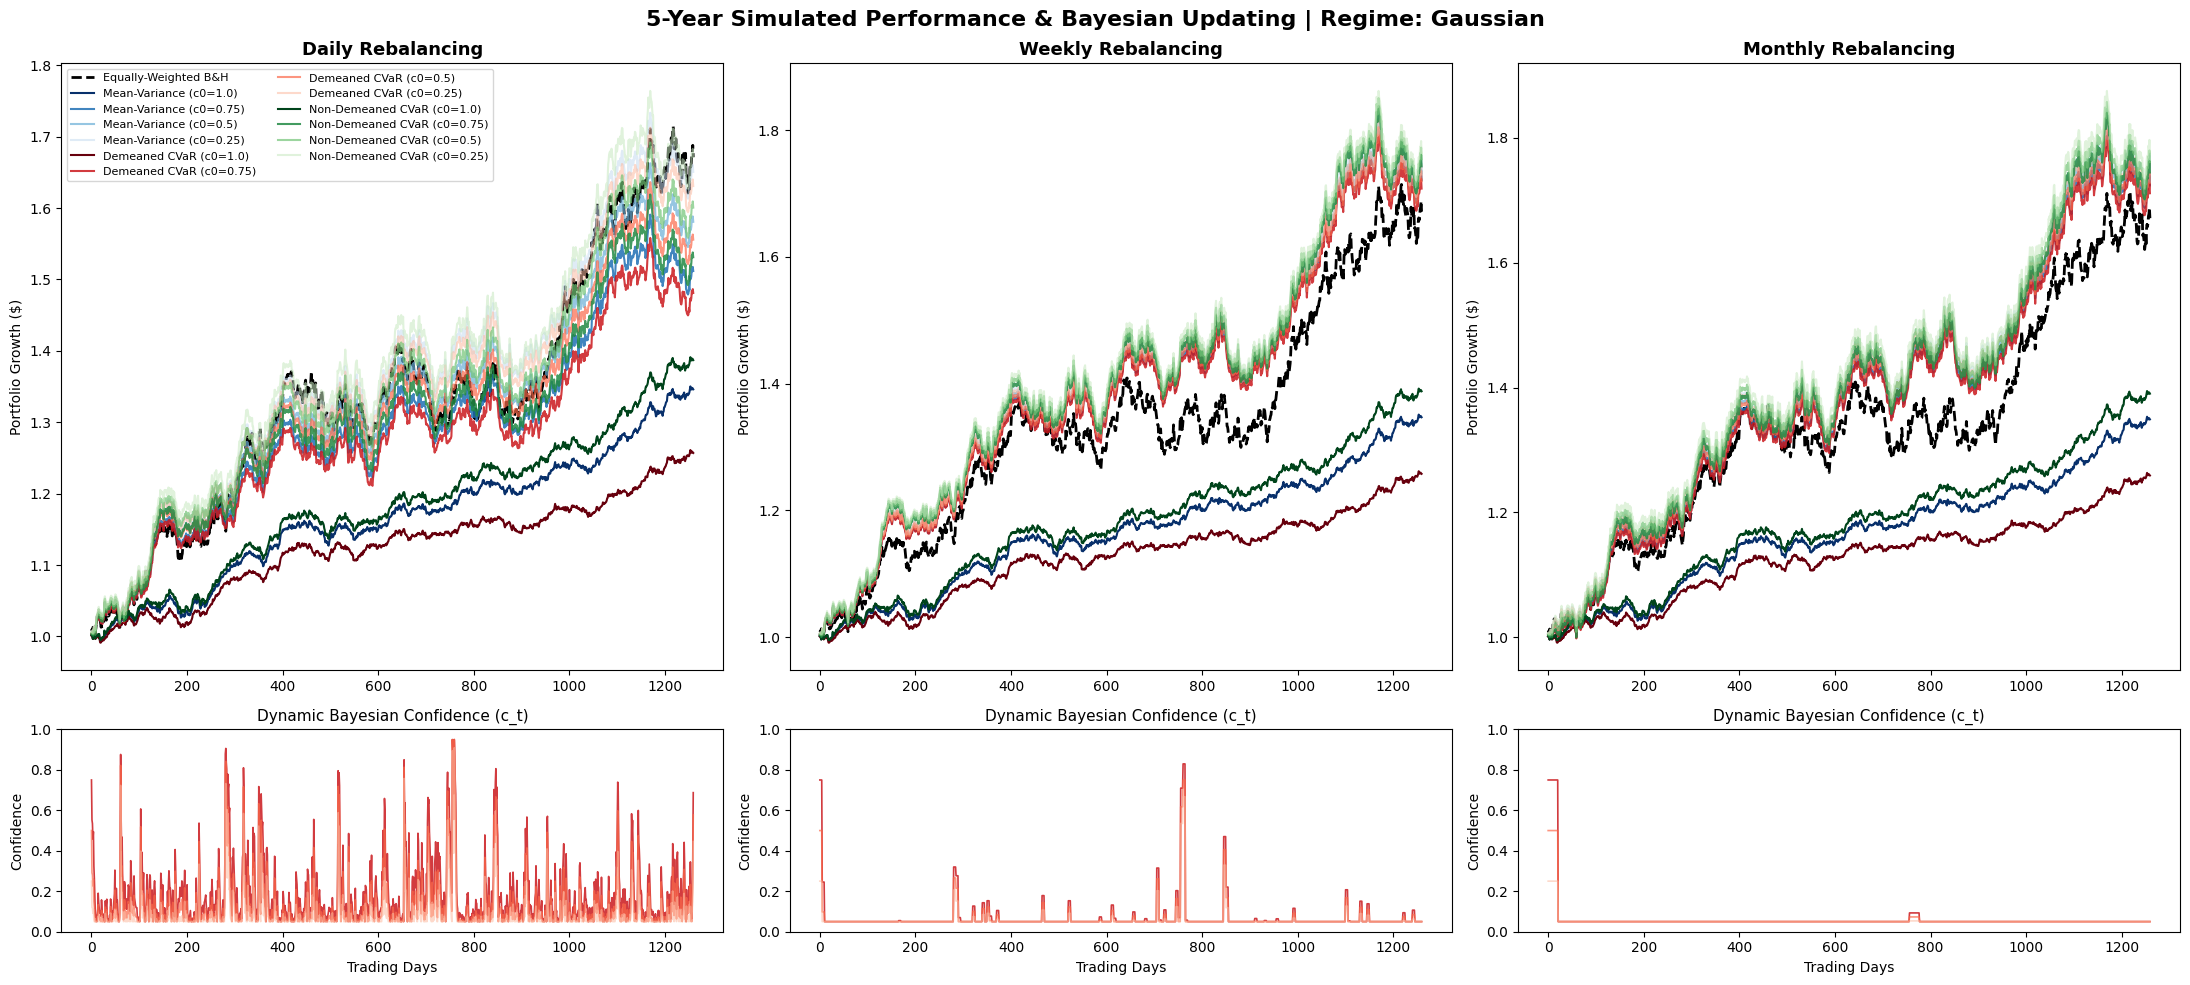

Processing Regimes:  20%|██        | 1/5 [01:16<05:04, 76.21s/it]

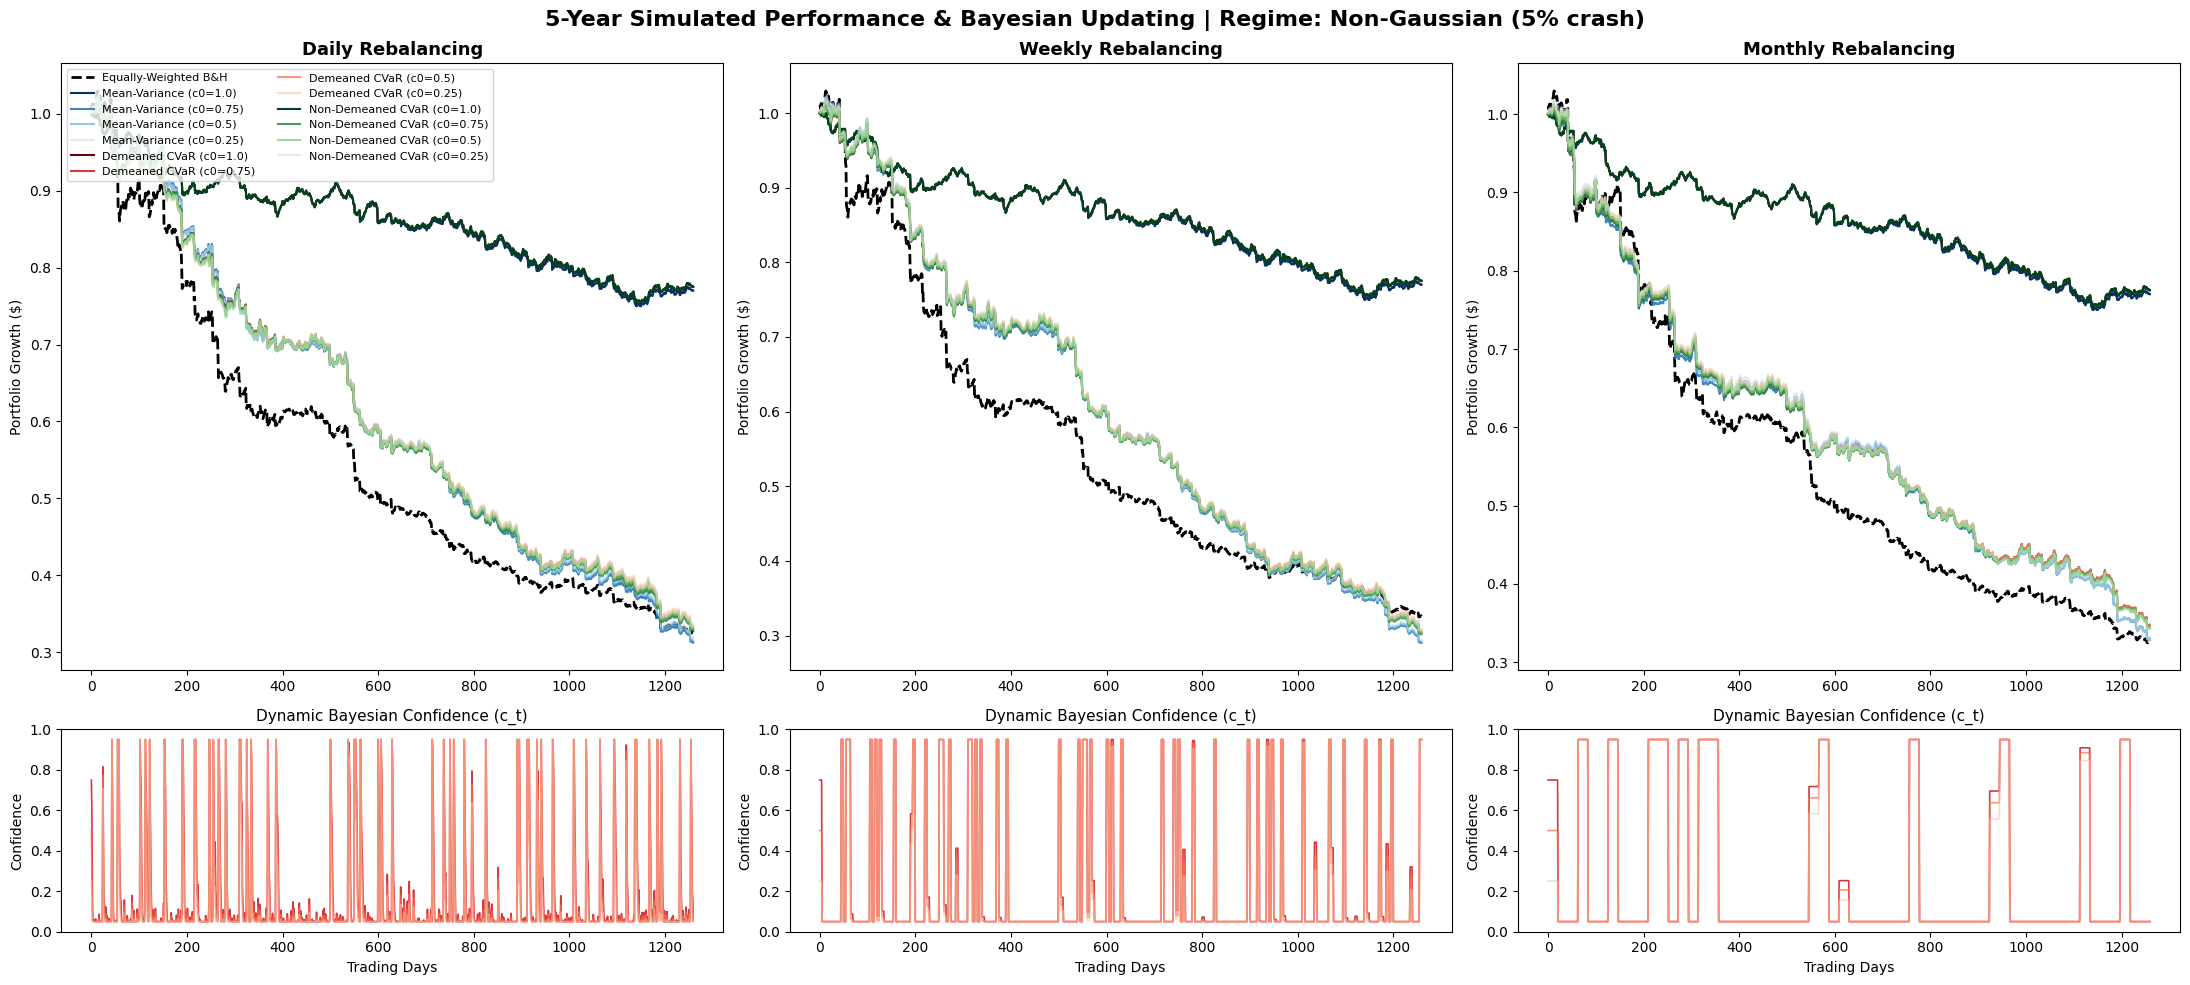

Processing Regimes:  40%|████      | 2/5 [02:28<03:41, 73.69s/it]

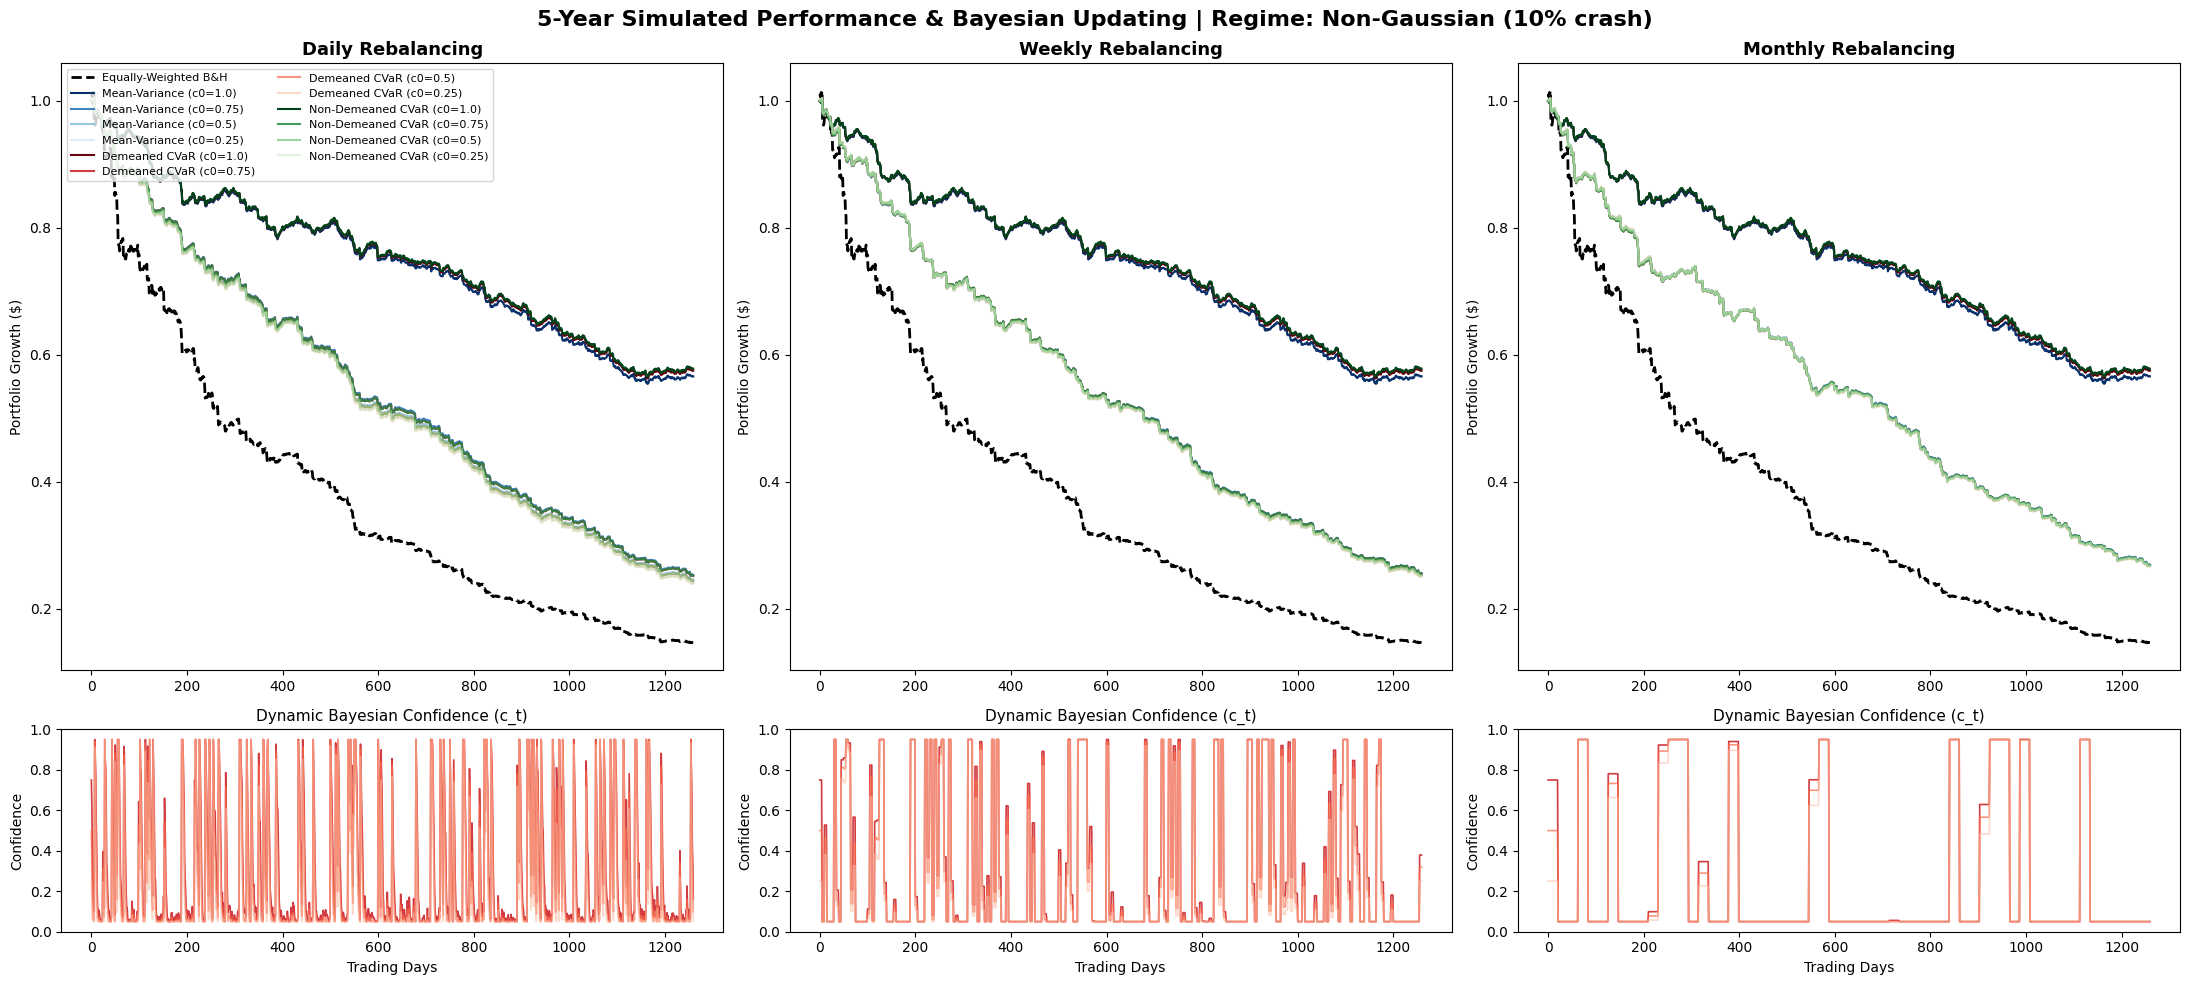

Processing Regimes:  60%|██████    | 3/5 [03:41<02:27, 73.64s/it]

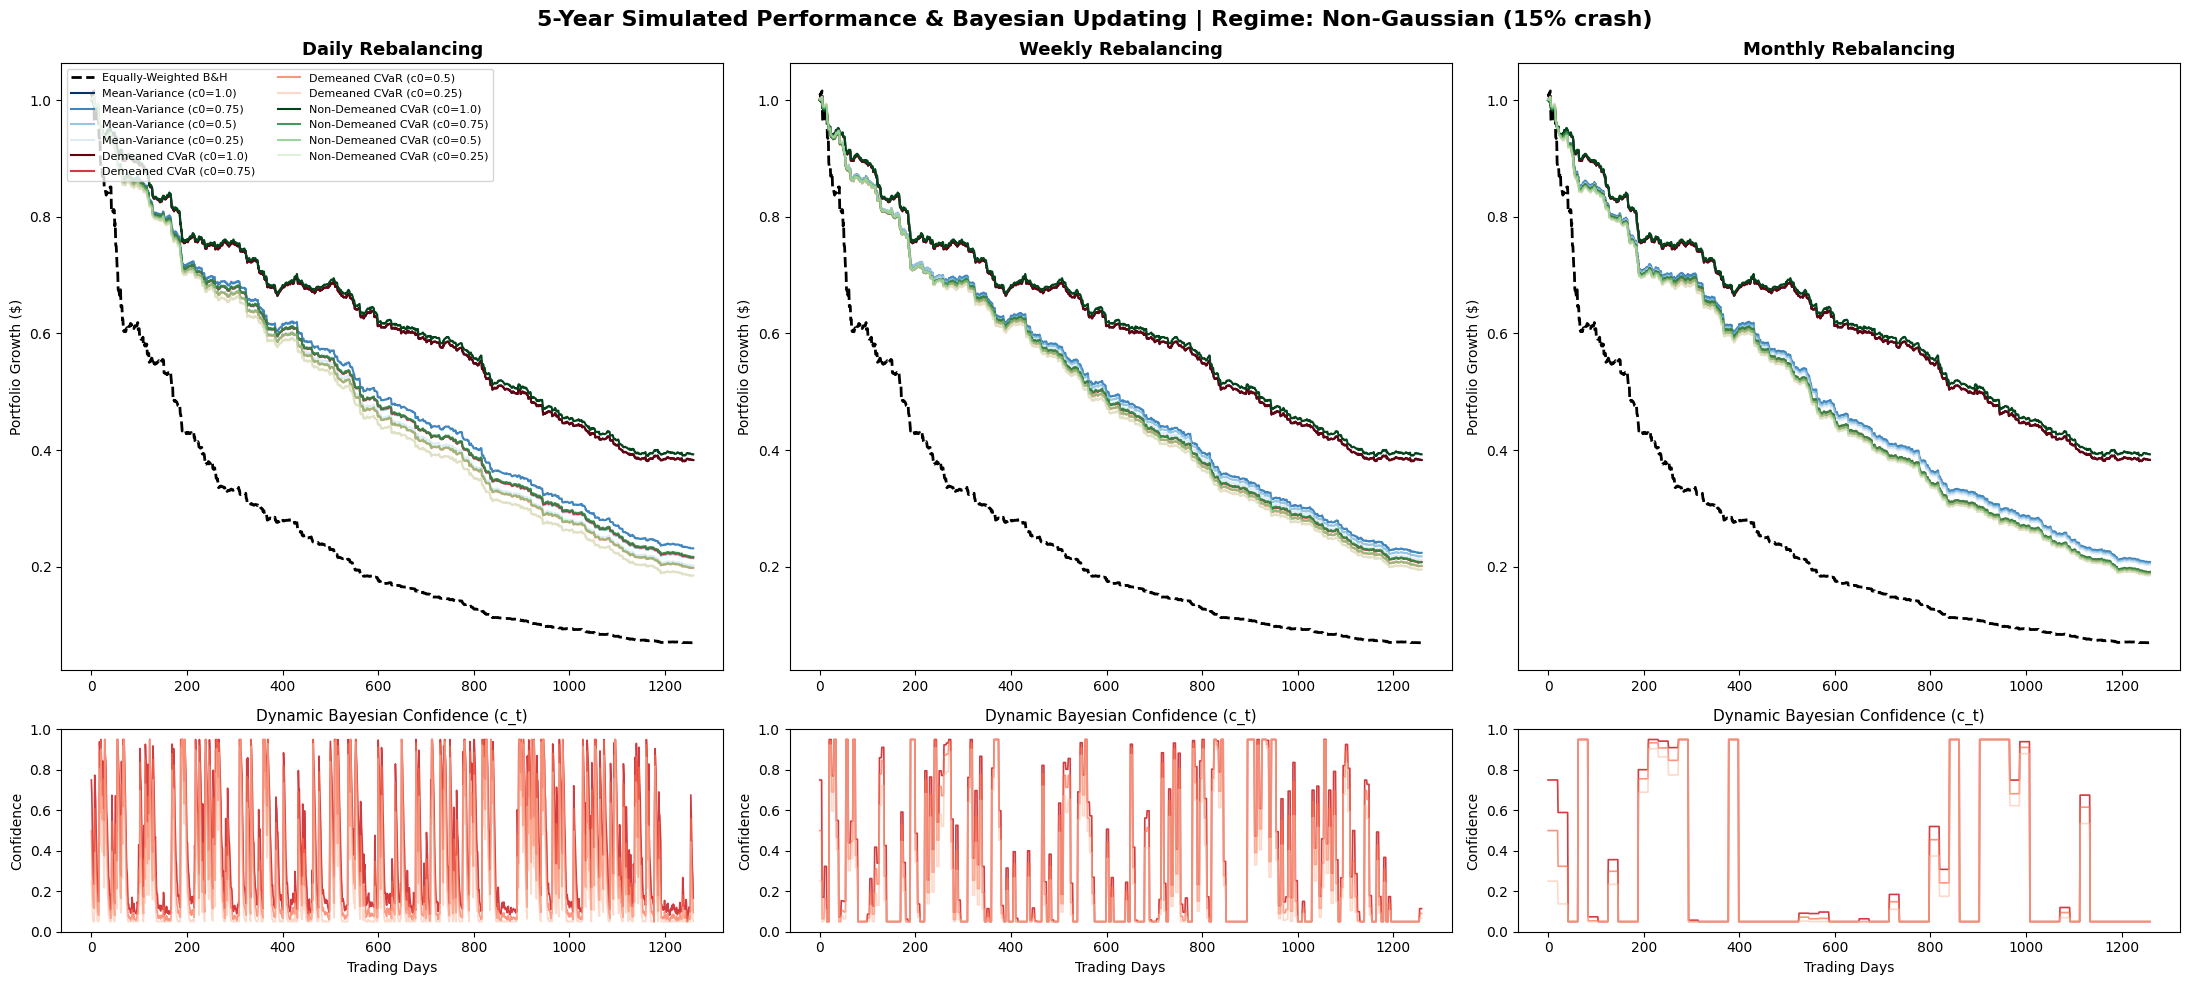

Processing Regimes:  80%|████████  | 4/5 [04:54<01:13, 73.29s/it]

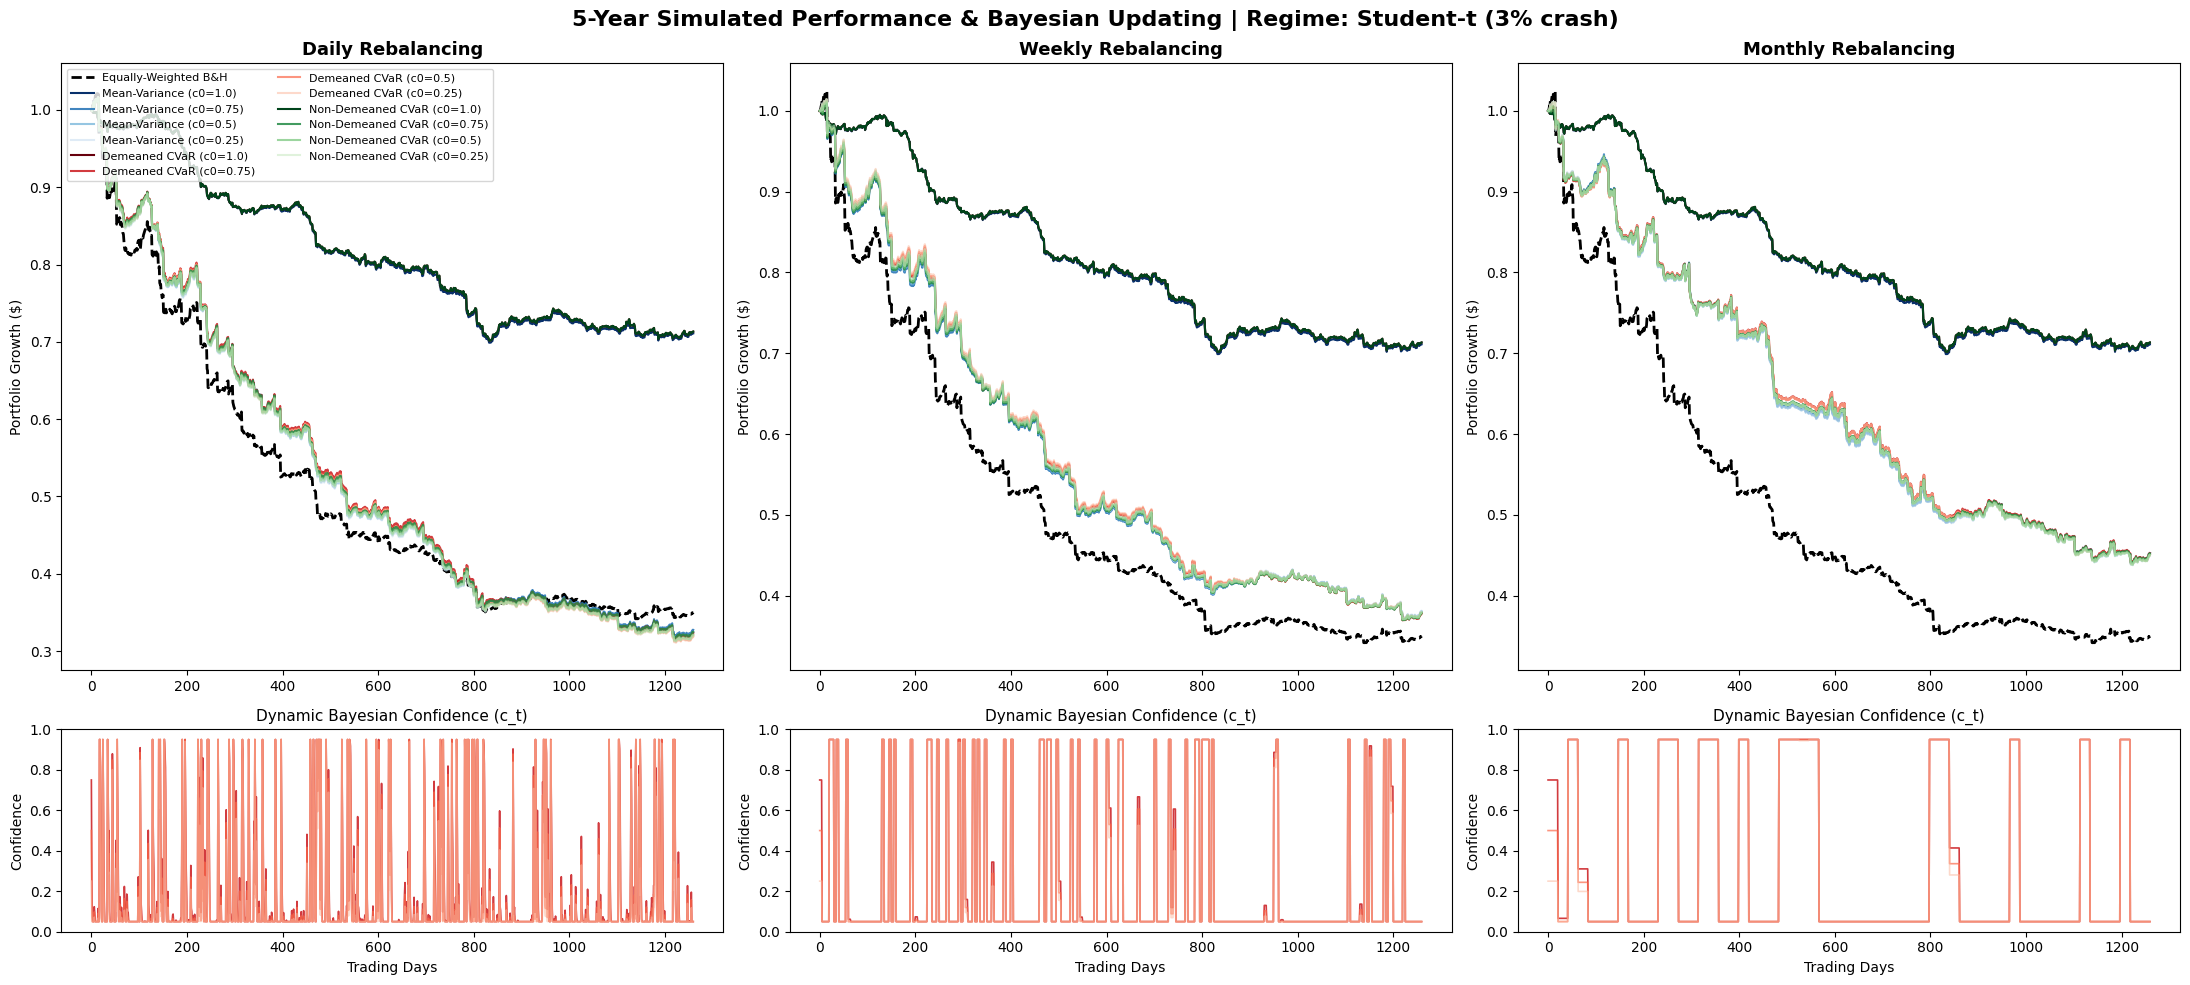

Processing Regimes: 100%|██████████| 5/5 [06:07<00:00, 73.53s/it]



 📊 5-YEAR OOS PERFORMANCE TABLE (DYNAMIC BAYESIAN WEIGHT BLENDING)
 P0 = Minimum Risk  |  P9 = Maximum Expected Return
 ⭐ = Buy & Hold (Equally-Weighted) Benchmark
 ✅ = Outperforms B&H on that specific metric
                                                                                        ⭐ B&H          P0          P1          P2          P3          P4          P5          P6          P7          P8          P9
Regime                   Model             Conf (c0) Rebalancing Metric                                                                                                                                              
Gaussian                 Mean-Variance     c0=1.00   Daily       Ann Ret (%)        ⭐ 10.8175      3.6007      3.9188      4.2436      4.7429      6.1234      7.5126      8.9102     10.3161   ✅ 11.7303   ✅ 13.1524
                                                                 Sharpe              ⭐ 1.1831    ✅ 1.4127    ✅ 1.5392    ✅ 1.6386    ✅ 1.7466    ✅ 1

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import fortitudo.tech as ft
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

# ==============================================================================
# 1. SIMULATE DATA & REGIMES (10 ASSETS)
# ==============================================================================
def generate_regime_scenarios_and_assets(regime_name, S=10000, seed=42, freq="annual"):
    np.random.seed(seed)
    N = 10

    # Table 1: Means and Volatilities
    means = np.array([-0.007, -0.004, 0.019, 0.027, 0.062, 0.077, 0.1284, 0.057, 0.0423, 0.0469])
    vols = np.array([0.032, 0.034, 0.060, 0.073, 0.139, 0.245, 0.241, 0.102, 0.078, 0.069])

    # Table 2: Correlation Matrix
    corr_matrix = np.array([[100,  60,   0,  30, -20, -10, -30, -10, -20, -20],[ 60, 100,  50,  60,  10,  20,  10,  10,  10,  30],[  0,  50, 100,  60,  60,  70,  60,  30,  30,  70],[ 30,  60,  60, 100,  40,  60,  30,  20,  20,  40],[-20,  10,  60,  40, 100,  70,  80,  40,  40,  80],[-10,  20,  70,  60,  70, 100,  70,  30,  40,  80],[-30,  10,  60,  30,  80,  70, 100,  40,  50,  80],[-10,  10,  30,  20,  40,  30,  40, 100,  40,  40],[-20,  10,  30,  20,  40,  40,  50,  40, 100,  50],[-20,  30,  70,  40,  80,  80,  80,  40,  50, 100],
    ]) / 100.0

    if freq == "daily":
        means = means / 252.0
        vols = vols / np.sqrt(252.0)
    elif freq != "annual":
        raise ValueError("Freq must be 'annual' or 'daily'")

    cov = np.diag(vols) @ corr_matrix @ np.diag(vols)
    chol = np.linalg.cholesky(cov)

    crash_mu = -3.0
    crash_vol_multiplier = 3.0

    def apply_mixture_model(p_crash, base_Z):
        Z_crash = crash_mu + crash_vol_multiplier * np.random.randn(S, N)
        is_crash = np.random.binomial(n=1, p=p_crash, size=(S, 1))
        return np.where(is_crash == 1, Z_crash, base_Z)

    if regime_name == "Gaussian":
        Z = np.random.randn(S, N)
    elif "15%" in regime_name:
        Z = apply_mixture_model(0.15, np.random.randn(S, N))
    elif "10%" in regime_name:
        Z = apply_mixture_model(0.10, np.random.randn(S, N))
    elif "5%" in regime_name:
        Z = apply_mixture_model(0.05, np.random.randn(S, N))
    elif "Student-t" in regime_name:
        Z = apply_mixture_model(0.03, stats.t.rvs(df=3, size=(S, N)) * np.sqrt(1/3))

    return (Z @ chol.T) + means


# ==============================================================================
# 2. BACKTEST ENGINE & BAYESIAN UPDATING
# ==============================================================================
def run_backtest_path_bayes(R_oos, w_prior_target, w_post_target, mu_p_d, cov_p_d, mu_q_d, cov_q_d, c_start, freq_days, is_bh=False):
    T, N = R_oos.shape
    w_current = np.ones(N) / N

    # Regularize daily covariances to prevent singular matrices in logpdf
    cov_p_d = cov_p_d + np.eye(N) * 1e-8
    cov_q_d = cov_q_d + np.eye(N) * 1e-8

    portfolio_returns =[]
    turnover_tracker = 0.0
    c_t = c_start
    c_history =[c_t]

    if not is_bh:
        w_current = (1 - c_t) * w_prior_target + c_t * w_post_target

    for t in range(T):
        r_t = R_oos[t]
        cost = 0.0

        if not is_bh and t > 0 and t % freq_days == 0:
            chunk = R_oos[t - freq_days : t]

            if 0.0 < c_t < 1.0:
                forgetting_factor = 0.90
                c_t = c_t * forgetting_factor + c_start * (1 - forgetting_factor)

                try:
                    ll_p = np.sum(stats.multivariate_normal.logpdf(chunk, mean=mu_p_d, cov=cov_p_d, allow_singular=True))
                    ll_q = np.sum(stats.multivariate_normal.logpdf(chunk, mean=mu_q_d, cov=cov_q_d, allow_singular=True))

                    max_ll = max(ll_p, ll_q)
                    P_E_given_H = np.exp(ll_q - max_ll)
                    P_E_given_not_H = np.exp(ll_p - max_ll)

                    P_E = (P_E_given_H * c_t) + (P_E_given_not_H * (1 - c_t))

                    if P_E > 0:
                        c_t = (P_E_given_H * c_t) / P_E
                except:
                    pass

                c_t = np.clip(c_t, 0.05, 0.95)

            # Dynamically blend portfolio target based on Bayesian Evidence
            w_target = (1 - c_t) * w_prior_target + c_t * w_post_target

            trade_amount = np.sum(np.abs(w_target - w_current))
            turnover_tracker += trade_amount
            cost = trade_amount * 0.0005 # 5 bps
            w_current = w_target.copy()

        c_history.append(c_t)
        net_ret = np.dot(w_current, r_t) - cost
        portfolio_returns.append(net_ret)

        denom = 1.0 + np.dot(w_current, r_t)
        w_current = w_current * (1.0 + r_t) / denom if denom > 0 else w_current

    return np.array(portfolio_returns), turnover_tracker, np.array(c_history[1:])

def compute_metrics(rets, turnover, method, freq_name, c, port_idx, regime):
    cum = np.cumprod(1 + rets)
    tot_ret = cum[-1] - 1
    ann_ret = (1 + tot_ret)**(252/len(rets)) - 1
    var = np.var(rets) * 252
    ann_vol = np.sqrt(var)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    neg_r = rets[rets < 0]
    sortino = ann_ret / (np.std(neg_r) * np.sqrt(252)) if len(neg_r) > 0 else 0
    peak = np.maximum.accumulate(cum)
    mdd = np.min((cum - peak) / peak)
    calmar = ann_ret / abs(mdd) if mdd < 0 else np.nan
    skew = pd.Series(rets).skew()
    kurt = pd.Series(rets).kurtosis()
    ann_to = turnover / (len(rets) / 252)

    return {
        "Regime": regime, "Method": method, "Freq": freq_name, "Conf (c0)": c, "Portfolio": port_idx,
        "Ann Ret (%)": ann_ret * 100,
        "Sharpe": sharpe, "Sortino": sortino, "Calmar": calmar,
        "Variance": var, "Max DD (%)": mdd * 100, "Skew": skew, "Kurtosis": kurt,
        "Yr. Turnover (x)": ann_to}

# ==============================================================================
# 3. TABLE FORMATTER
# ==============================================================================
def format_table(df_metrics):
    df = df_metrics.copy()
    higher_is_better =["Ann Ret (%)", "Sharpe", "Sortino", "Calmar"]
    lower_is_better =["Variance", "Yr. Turnover (x)"]
    p_order = list(range(10))

    id_cols =["Regime", "Method", "Freq", "Conf (c0)", "Portfolio"]
    metric_cols =[c for c in df.columns if c not in id_cols]
    df_bh = df[df["Method"] == "B&H"].copy()

    def fmt_cell(metric, val, bh_val, is_bh=False):
        if pd.isna(val): return "N/A"
        if is_bh: return f"⭐ {val:.4f}"
        outperform = False
        if metric in higher_is_better and val > bh_val: outperform = True
        elif metric in lower_is_better and val < bh_val: outperform = True
        elif metric == "Max DD (%)" and val > bh_val: outperform = True
        prefix = "✅ " if outperform else ""
        return f"{prefix}{val:.4f}"

    def build_block(df_sub, bh_row):
        df_wide = df_sub.set_index("Portfolio")[metric_cols].sort_index().T
        out = pd.DataFrame(index=df_wide.index)
        out["⭐ B&H"] = bh_row[df_wide.index].astype(float).values

        for p in p_order:
            out[f"P{p}"] = df_wide[p].astype(float).values if p in df_wide.columns else np.nan

        formatted = pd.DataFrame(index=out.index, columns=out.columns, dtype=object)
        for metric in out.index:
            bh_val = out.loc[metric, "⭐ B&H"]
            formatted.loc[metric, "⭐ B&H"] = fmt_cell(metric, bh_val, bh_val, is_bh=True)
            for col in out.columns:
                if col == "⭐ B&H": continue
                formatted.loc[metric, col] = fmt_cell(metric, out.loc[metric, col], bh_val, is_bh=False)
        return formatted

    blocks, index_tuples = [],[]
    for regime in sorted(df["Regime"].unique()):
        bh_row_reg = df_bh[df_bh["Regime"] == regime].iloc[0]

        for method in["Mean-Variance", "Demeaned CVaR", "Non-Demeaned CVaR"]:
            for c0 in[1.0, 0.75, 0.50, 0.25]:
                for freq in["Daily", "Weekly", "Monthly"]:
                    df_block = df[(df["Regime"] == regime) & (df["Method"] == method) &
                                  (df["Conf (c0)"] == c0) & (df["Freq"] == freq)].copy()
                    if df_block.empty: continue

                    df_block["Portfolio"] = df_block["Portfolio"].astype(int)
                    block_tbl = build_block(df_block, bh_row_reg)

                    for metric in block_tbl.index:
                        index_tuples.append((regime, method, f"c0={c0:.2f}", freq, metric))
                    blocks.append(block_tbl)

    final = pd.concat(blocks, axis=0)
    final.index = pd.MultiIndex.from_tuples(index_tuples, names=["Regime", "Model", "Conf (c0)", "Rebalancing", "Metric"])
    return final


# ==============================================================================
# 4. MAIN ENGINE: PORTFOLIO EXECUTION SUITE
# ==============================================================================
def execute_pipeline():
    S_prior = 15000
    S_oos = 1260
    N = 10
    num_portfolios = 10
    c_values = [1.0, 0.75, 0.50, 0.25]
    freqs = {"Daily": 1, "Weekly": 5, "Monthly": 21}

    regimes =[
        "Gaussian", "Non-Gaussian (5% crash)", "Non-Gaussian (10% crash)",
        "Non-Gaussian (15% crash)", "Student-t (3% crash)"]

    all_metrics =[]

    print("Launching 5-Year Portfolio Simulations with Bayesian Upating...")
    for regime in tqdm(regimes, desc="Processing Regimes"):

        # 1. Prior Generation
        R_prior = generate_regime_scenarios_and_assets(regime, S=S_prior, seed=42, freq="annual")
        p = np.ones((S_prior, 1)) / S_prior

        mu_prior_daily = np.mean(R_prior, axis=0) / 252.0
        cov_prior_daily = np.cov(R_prior, rowvar=False) / 252.0

        # 2. Posterior (SeqEP View: DM Equity Mean = -10%, Vol = 30%)
        A0 = np.vstack((np.ones((1, S_prior)), R_prior[:, 4]))
        b0 = np.array([[1.0],[-0.10]])
        q0 = ft.entropy_pooling(p, A0, b0)
        consistent_mean_dm_equity = (q0.T @ R_prior).flatten()[4]

        vol_row = (R_prior[:, 4] - consistent_mean_dm_equity)**2
        A1 = np.vstack((np.ones((1, S_prior)), R_prior[:, 4], vol_row))
        b1 = np.array([[1.0],[consistent_mean_dm_equity], [0.30**2]])
        q1_full = ft.entropy_pooling(p, A1, b1)

        q1_probs = np.clip(q1_full.flatten(), 0, None)
        q1_probs /= np.sum(q1_probs)
        R_post = R_prior[np.random.choice(S_prior, size=S_prior, p=q1_probs), :]

        mu_post_daily = np.mean(R_post, axis=0) / 252.0
        cov_post_daily = np.cov(R_post, rowvar=False) / 252.0

        # 3. Obtain the Base Target Weights
        G, h = -np.eye(N), np.zeros(N)

        opt_var_prior = ft.MeanVariance(np.mean(R_prior, axis=0), np.cov(R_prior, rowvar=False), G, h)
        opt_cvar_dem_prior = ft.MeanCVaR(R_prior, G, h, options={'demean': True})
        opt_cvar_non_prior = ft.MeanCVaR(R_prior, G, h, options={'demean': False})

        W_prior_var = opt_var_prior.efficient_frontier(num_portfolios)
        W_prior_cvar_dem = opt_cvar_dem_prior.efficient_frontier(num_portfolios)
        W_prior_cvar_non = opt_cvar_non_prior.efficient_frontier(num_portfolios)

        opt_var_post = ft.MeanVariance(np.mean(R_post, axis=0), np.cov(R_post, rowvar=False), G, h)
        opt_cvar_dem_post = ft.MeanCVaR(R_post, G, h, options={'demean': True})
        opt_cvar_non_post = ft.MeanCVaR(R_post, G, h, options={'demean': False})

        W_post_var = opt_var_post.efficient_frontier(num_portfolios)
        W_post_cvar_dem = opt_cvar_dem_post.efficient_frontier(num_portfolios)
        W_post_cvar_non = opt_cvar_non_post.efficient_frontier(num_portfolios)

        models =[
            ("Mean-Variance", W_prior_var, W_post_var),
            ("Demeaned CVaR", W_prior_cvar_dem, W_post_cvar_dem),
            ("Non-Demeaned CVaR", W_prior_cvar_non, W_post_cvar_non)
        ]

        # 4. Out Of Sample Run
        R_oos = generate_regime_scenarios_and_assets(regime, S=S_oos, seed=99, freq="daily")
        rets_bh, _, _ = run_backtest_path_bayes(R_oos, None, None, mu_prior_daily, cov_prior_daily, mu_post_daily, cov_post_daily, 1.0, 1, is_bh=True)
        all_metrics.append(compute_metrics(rets_bh, 0, "B&H", "N/A", "N/A", "N/A", regime))

        # Visualization
        fig, axes = plt.subplots(2, 3, figsize=(22, 10), gridspec_kw={"height_ratios":[3, 1]})
        fig.suptitle(f"5-Year Simulated Performance & Bayesian Updating | Regime: {regime}", fontsize=16, fontweight="bold")
        color_map = {"Mean-Variance": "Blues", "Demeaned CVaR": "Reds", "Non-Demeaned CVaR": "Greens"}

        for ax_idx, (freq_name, freq_days) in enumerate(freqs.items()):
            ax_perf = axes[0, ax_idx]
            ax_conf = axes[1, ax_idx]

            ax_perf.plot(np.cumprod(1 + rets_bh), label="Equally-Weighted B&H", color="black", linestyle="--", linewidth=2)

            for method_name, W_prior, W_post in models:
                for c_start in c_values:
                    for p_idx in range(num_portfolios):
                        w_p_target = W_prior[:, p_idx]
                        w_q_target = W_post[:, p_idx]

                        rets, to, c_hist = run_backtest_path_bayes(
                            R_oos, w_p_target, w_q_target, mu_prior_daily, cov_prior_daily, mu_post_daily, cov_post_daily, c_start, freq_days)

                        all_metrics.append(compute_metrics(rets, to, method_name, freq_name, c_start, p_idx, regime))

                        # Plot ONLY the Balanced Portfolio (P4) to keep visual clear
                        if p_idx == 4:
                            cmap = plt.get_cmap(color_map[method_name])
                            alpha = 0.4 + (c_start * 0.6)
                            ax_perf.plot(np.cumprod(1 + rets), label=f"{method_name} (c0={c_start})", color=cmap(c_start), linewidth=1.5, alpha=alpha)

                            if c_start != 1.0 and method_name == "Demeaned CVaR": # Plot confidence trace only once per regime
                                ax_conf.plot(c_hist, color=cmap(c_start), linewidth=1.2, alpha=alpha)

            ax_perf.set_title(f"{freq_name} Rebalancing", fontsize=13, fontweight="bold")
            ax_perf.set_ylabel("Portfolio Growth ($)")

            ax_conf.set_title("Dynamic Bayesian Confidence (c_t)", fontsize=11)
            ax_conf.set_ylim(0, 1.0)
            ax_conf.set_xlabel("Trading Days")
            ax_conf.set_ylabel("Confidence")

            if ax_idx == 0:
                ax_perf.legend(loc="upper left", fontsize=8, ncol=2)

        plt.tight_layout()
        plt.show()

    df_metrics = pd.DataFrame(all_metrics)
    final_table = format_table(df_metrics)
    return final_table, df_metrics

# ==============================================================================
# 5. VISUALIZATION ENGINE
# ==============================================================================
if __name__ == "__main__":
    final_table, df_metrics = execute_pipeline()

    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 2500)

    print("\n" + "=" * 180)
    print(" 📊 5-YEAR OOS PERFORMANCE TABLE (DYNAMIC BAYESIAN WEIGHT BLENDING)")
    print(" P0 = Minimum Risk  |  P9 = Maximum Expected Return")
    print(" ⭐ = Buy & Hold (Equally-Weighted) Benchmark")
    print(" ✅ = Outperforms B&H on that specific metric")
    print("=" * 180)
    print(final_table)